# 11 · Model Değerlendirme Metrikleri (Sınıflandırma ve Regresyon)
**Classical ML Lab** · Confusion Matrix, ROC/PR Eğrileri, Çok Sınıflı Ortalamalar, Kalibrasyon, Regresyon Hata Metrikleri

---
> **Bu notebook'ta ne öğreneceğiz?**
> Şimdiye kadarki notebook'larda (02-10) modelleri neredeyse hep `accuracy_score` ya da varsayılan `.score()` ile değerlendirdik — ama bu, roadmap'in bu kategoriyi ("Model Değerlendirme ve İyileştirme") ayrı ve kritik bir başlık olarak ayırmasının nedenini gizliyordu: **accuracy, dengesiz (imbalanced) veya asimetrik-maliyetli problemlerde yanıltıcı, hatta tehlikeli olabilir.** Bu notebook'ta: (1) confusion matrix'ten türeyen tüm ikili metrikleri (precision, recall, F1, F-beta, MCC, Cohen's kappa) hem elle hem `sklearn` ile inşa edeceğiz, (2) eşikten bağımsız değerlendirme için ROC/AUC ve Precision-Recall/Average Precision eğrilerini kuracağız ve ne zaman hangisinin güvenilir olduğunu göreceğiz, (3) çok sınıflı problemlerde macro/micro/weighted ortalamaların NEDEN farklı sonuç verdiğini aşırı dengesiz gerçek bir veri setinde (Ecoli) göstereceğiz, (4) bir modelin ürettiği olasılıkların gerçekten "doğru" olup olmadığını (kalibrasyon) reliability diagram ve Brier skoruyla ölçüp Platt/isotonic kalibrasyonla düzelteceğiz, (5) regresyon tarafında MAE/RMSE/MAPE/R² gibi metriklerin aykırı değerlere ve ölçeğe farklı tepki verdiğini somut bir deneyle karşılaştıracağız, ve (6) en sonda "hangi problemde hangi metrik" için pratik bir karar rehberi çıkaracağız. Bu notebook'un asıl amacı, iş dünyasında bir modeli "iyi" ilan etmeden önce doğru soruyu sormayı öğretmek.
>
> **Önkoşul:** `03_linear_classification_family` (Logistic Regression, LDA/QDA), `08_decision_trees`/`09_bagging_random_forest` (Random Forest), temel olasılık ([[Probability-lab]]).
> **Veri:** Statlog (German Credit Data) — UCI, ikili & dengesiz (700/300) kredi riski sınıflandırması; Ecoli — UCI, 8 sınıflı & aşırı dengesiz protein lokalizasyon sınıflandırması; Boston Housing — UCI, konut fiyatı regresyonu.
> **Araçlar:** `scikit-learn.metrics`, R `pROC`/`caret`/`Metrics`, DuckDB (SQL).

---
## 1 · Neden Metrik Seçimi Önemli? Accuracy Tuzağı

**Accuracy paradoksu.** Accuracy, $\dfrac{\text{doğru tahmin sayısı}}{\text{toplam tahmin sayısı}}$ olarak tanımlanır ve sezgisel olarak en "doğal" metrik gibi görünür. Ancak sınıflar dengesiz olduğunda son derece yanıltıcı olabilir. Bu notebook'ta kullanacağımız German Credit veri setinde 1000 krediden 700'ü "iyi" (class=1), 300'ü "kötü" (class=2) risktir. **Hiçbir şey öğrenmeyen, her zaman "iyi kredi" diyen aptal bir model bile %70 accuracy elde eder** — çünkü çoğunluk sınıfını tahmin etmek, dengesiz bir veri setinde ücretsiz bir "başarı" sağlar. Bu modelin gerçek değeri sıfırdır (hiçbir kötü krediyi yakalayamaz), ama yalnızca accuracy'ye bakan biri onu "iyi bir model" sanabilir.

**Endüstride nerede karşımıza çıkar?** Dolandırıcılık tespitinde (fraud detection) işlemlerin genelde <%1'i dolandırıcılıktır — "hiçbir işlem dolandırıcılık değildir" diyen bir model %99+ accuracy alır ama işe yaramaz. Tıbbi tarama testlerinde (örneğin nadir bir hastalık için tarama) hasta olmayanların oranı ezici çoğunluktadır; aynı tuzak geçerlidir. Üretim hattı kalite kontrolünde (defect detection) kusurlu ürün oranı genelde çok düşüktür (örn. %0.5) — "hiçbir ürün kusurlu değil" diyen bir model %99.5 accuracy'ye rağmen tüm kusurlu ürünleri kaçırır.

**Bu neden önemli?** Bir metrik seçmeden önce sormamız gereken soru accuracy değil, **"hangi hata türü (False Positive mi False Negative mi) bize daha pahalıya mal olur?"** sorusudur. Geri kalan bölümlerde bu soruyu yanıtlayacak araç setini inşa edeceğiz.

---
## 2 · Confusion Matrix ve Temel İkili Sınıflandırma Metrikleri

**Confusion Matrix.** İkili sınıflandırmada dört olası sonuç vardır (pozitif sınıf = "ilgilendiğimiz olay", örn. kötü kredi, dolandırıcılık, hastalık):

| | Tahmin: Pozitif | Tahmin: Negatif |
|---|---|---|
| **Gerçek: Pozitif** | True Positive (TP) | False Negative (FN) — Tip II Hata |
| **Gerçek: Negatif** | False Positive (FP) — Tip I Hata | True Negative (TN) |

**Temel metrikler (hepsi bu dört sayıdan türer):**

$$\text{Accuracy} = \frac{TP+TN}{TP+TN+FP+FN} \qquad \text{Precision} = \frac{TP}{TP+FP} \qquad \text{Recall (Sensitivity, TPR)} = \frac{TP}{TP+FN}$$

$$\text{Specificity (TNR)} = \frac{TN}{TN+FP} \qquad F_1 = 2\cdot\frac{\text{Precision}\cdot\text{Recall}}{\text{Precision}+\text{Recall}} \qquad F_\beta = (1+\beta^2)\cdot\frac{\text{Precision}\cdot\text{Recall}}{\beta^2\cdot\text{Precision}+\text{Recall}}$$

**Precision vs Recall — asimetrik maliyet.** Precision, "pozitif dediklerimin kaçı gerçekten pozitif" sorusuna (FP'lerin maliyetine duyarlı); recall "gerçek pozitiflerin kaçını yakaladım" sorusuna (FN'lerin maliyetine duyarlı) cevap verir. $F_\beta$'daki $\beta$ parametresi bu ikisi arasındaki göreli önemi ayarlar: $\beta > 1$ recall'a, $\beta < 1$ precision'a daha çok ağırlık verir ($\beta=2$ ve $\beta=0.5$ pratikte en sık kullanılanlardır).

**Balanced Accuracy.** Dengesiz veri için accuracy'nin düzeltilmiş hali: $\text{Balanced Accuracy} = \frac{1}{2}(\text{Recall} + \text{Specificity})$ — her iki sınıfın hatasını eşit ağırlıklandırır, çoğunluk sınıfını tahmin ederek "ücretsiz" yüksek skor almayı engeller.

**Matthews Correlation Coefficient (MCC).** Dört hücreyi de simetrik biçimde kullanan, $[-1, 1]$ aralığında tek bir sayı (0 = rastgele tahmin, 1 = mükemmel, -1 = tamamen ters):

$$\text{MCC} = \frac{TP \cdot TN - FP \cdot FN}{\sqrt{(TP+FP)(TP+FN)(TN+FP)(TN+FN)}}$$

Dengesiz verilerde F1'den bile daha güvenilir kabul edilir çünkü paydadaki dört terimin herhangi biri sıfır olursa (örn. model hiç pozitif tahmin etmezse) MCC otomatik olarak 0'a düşer — F1 gibi tanımsız (0/0) durumuna düşüp gizlice iyimser bir varsayılan değere yuvarlanmaz.

**Cohen's Kappa.** Gözlenen uyumun (accuracy), *rastgele şansla* beklenen uyumdan ne kadar fazla olduğunu ölçer: $\kappa = \dfrac{p_o - p_e}{1 - p_e}$ ($p_o$: gözlenen uyum/accuracy, $p_e$: şans-beklenen uyum, sınıf oranlarından hesaplanır). $\kappa=0$ rastgele tahminle aynı performans, $\kappa=1$ mükemmel uyum demektir; dengesiz verilerde ham accuracy'den daha anlamlıdır çünkü $p_e$ terimi çoğunluk-sınıf tahmininin "ücretsiz" başarısını çıkarır.

**Endüstride nerede kullanılır?** E-posta spam filtrelemede **precision** önceliklidir — bir FP (gerçek bir iş e-postasının spam'e düşmesi) kullanıcı için FN'den (bir spam'in gelen kutusuna sızması) çok daha rahatsız edicidir. Kanser taramasında **recall** önceliklidir — bir FN (gerçek bir kanser vakasının kaçırılması) hayati risk taşırken, bir FP (yanlış alarm) ek bir testle düzeltilebilir; bu yüzden tarama testleri genelde yüksek recall/düşük precision'a bilinçli olarak ayarlanır. **MCC**, tam da tanımlandığı alan olan biyoinformatikte (protein ikincil yapı tahmini, Matthews 1975) hâlâ standarttır — bu notebook'ta kullanacağımız Ecoli veri setiyle aynı alan. **Cohen's Kappa**, iki insan etiketleyicinin (annotator) aynı veri üzerinde ne kadar hemfikir olduğunu ölçmek için içerik moderasyonu ve tıbbi teşhis QA süreçlerinde (etiketleme kalitesini doğrulamak amacıyla) yaygın kullanılır — model-insan uyumunu ölçmek için de aynı formül geçerlidir.

---
## 3 · Eşikten Bağımsız Değerlendirme: ROC Eğrisi ve AUC

**Neden eşikten bağımsız?** Bölüm 2'deki tüm metrikler (precision, recall, F1...) tek bir karar eşiğine (genelde $\hat{p} \geq 0.5$) bağlıdır. Ama bir sınıflandırıcı aslında bir **olasılık/skor** üretir; eşiği 0.3 ya da 0.7 seçmek tamamen bizim elimizdedir ve iş bağlamına göre değişir. ROC eğrisi, **her olası eşik için** True Positive Rate (recall) ve False Positive Rate'i ($FPR = FP/(FP+TN) = 1-\text{specificity}$) hesaplayıp $FPR$'a karşı $TPR$'yi çizerek modelin *tüm eşik aralığındaki* ayırt etme gücünü tek bir eğride özetler.

**İnşa.** Skorlar azalan sırayla dizilir; her benzersiz skor bir eşik adayı olur. Eşik en yükseğe ayarlandığında hiçbir şey pozitif tahmin edilmez ($TPR=FPR=0$, eğrinin sol-alt köşesi); eşik en düşüğe indirildiğinde her şey pozitif tahmin edilir ($TPR=FPR=1$, sağ-üst köşe). Eğri bu iki nokta arasında, eşik azaldıkça artan $TPR$/$FPR$ çiftlerini birleştirir.

**AUC (Area Under the Curve) yorumu.** AUC'nin çok kullanışlı, olasılıksal bir yorumu vardır: **rastgele seçilen bir pozitif örneğin, rastgele seçilen bir negatif örnekten daha yüksek skor alma olasılığıdır** ($P(\hat{p}_{\text{pos}} > \hat{p}_{\text{neg}})$ — bu aynı zamanda Mann-Whitney U istatistiğiyle birebir ilişkilidir). $AUC=0.5$ rastgele tahmin (köşegen çizgi), $AUC=1.0$ mükemmel ayrım demektir. AUC'nin kritik özelliği: **sınıf dengesizliğinden ROC-AUC değeri kendisi doğrudan etkilenmez** (hem $TPR$ hem $FPR$ kendi sınıfları içinde normalize edilmiş oranlardır) — ama Bölüm 4'te göreceğimiz gibi bu, aşırı dengesizlikte *yanıltıcı bir rahatlık hissi* de verebilir.

**Youden's J İstatistiği ile Optimal Eşik Seçimi.** Tek bir karar noktasına ihtiyaç duyduğumuzda (örn. üretime koyacağımız model), $J = TPR - FPR = \text{Sensitivity} + \text{Specificity} - 1$'i maksimize eden eşik, ROC eğrisi üzerinde köşegenden en uzak noktadır — sensitivity ve specificity arasında eşit ağırlıklı bir dengeyi temsil eder (maliyetler simetrikse iyi bir başlangıç noktasıdır; asimetrik maliyetlerde Bölüm 8'deki maliyet-ağırlıklı eşik seçimi daha doğrudur).

**Endüstride nerede kullanılır?** Kredi skorlama sistemlerinde bankalar, bir skor kartının (scorecard) genel ayırt etme gücünü raporlarken hemen her zaman AUC (bazen "Gini katsayısı" $=2\cdot AUC-1$ adıyla) kullanır — düzenleyici kurumlara sunulan model doğrulama raporlarının standart bir parçasıdır. Tıbbi tanı testlerinde (örn. bir biyobelirteç seviyesinin hastalığı öngörme gücü) ROC analizi epidemiyolojinin temel araçlarından biridir ve Youden's J, bir biyobelirtecin "pozitif" sayılacağı klinik eşiği belirlemek için yaygın kullanılır (Fluss ve ark. 2005). Youden'in kendisi bu istatistiği 1950'de tam olarak bu amaçla (tanı testi değerlendirmesi) önermiştir.

---
## 4 · Precision-Recall Eğrisi ve Average Precision

**ROC'un kör noktası: aşırı dengesizlik.** ROC-AUC, $FPR = FP/(FP+TN)$ kullanır — paydadaki $TN$ terimi, negatif sınıf çoğunluktaysa çok büyük olur ve *çok sayıda* FP bile $FPR$'ı görece küçük tutar. Sonuç: aşırı dengesiz verilerde (örn. %1 pozitif sınıf) bir model onlarca kat fazla yanlış alarm üretse bile ROC eğrisi hâlâ "iyi" görünebilir. **Precision-Recall (PR) eğrisi** bunun yerine $Precision = TP/(TP+FP)$ kullanır — paydasında $TN$ yoktur, dolayısıyla FP'lerin gerçek etkisini (pozitif tahminlerin ne kadarının "boşa" gittiğini) doğrudan yansıtır.

**İnşa ve Average Precision (AP).** ROC gibi PR eğrisi de eşik taranarak inşa edilir: her eşik için recall'a karşı precision çizilir. Eğrinin altındaki alanın (PR-AUC) doğrudan yorumlanması ROC-AUC kadar sezgisel değildir (precision, recall'un monoton bir fonksiyonu olmadığından enterpolasyon karmaşıklaşır); bunun yerine pratikte **Average Precision (AP)** tercih edilir — her recall seviyesinde elde edilen precision'ın, ardışık recall artışlarıyla ağırlıklandırılmış toplamıdır: $AP = \sum_n (R_n - R_{n-1}) \cdot P_n$. AP, bilgi erişiminde (information retrieval) kullanılan aynı formülasyondur.

**Baseline farkı — kritik bir nüans.** ROC'ta rastgele tahminin AUC'si her zaman 0.5'tir (veri dengesinden bağımsız). PR eğrisinde ise rastgele bir modelin AP'si **pozitif sınıf oranına eşittir** ($\pi$) — %1 pozitif sınıflı bir problemde rastgele AP $\approx 0.01$, ama %50/50 dengeli bir problemde rastgele AP $\approx 0.5$'tir. Bu yüzden PR-AUC/AP değerleri **farklı veri setleri arasında karşılaştırılamaz** — her zaman kendi baseline'ına (pozitif sınıf oranına) göre yorumlanmalıdır.

**Endüstride nerede kullanılır?** Kredi kartı dolandırıcılığı tespitinde (işlemlerin ~%0.1-0.5'i dolandırıcılık) PR-AUC/AP, ROC-AUC'den çok daha güvenilir bir sıralama kriteridir — Davis & Goadrich (2006) bu ayrımı tam olarak bu tür aşırı dengesiz problemler için formalize etmiştir. Arama motorlarında ve öneri sistemlerinde (search/recommendation) "ilk $k$ sonuçtaki precision" (precision@k) ve AP, sıralama kalitesinin standart ölçütüdür. Nadir hastalık taramasında (örn. binde birden az görülen genetik bir durum) PR eğrisi, ROC'un gizleyebileceği "gerçekte kaç yanlış pozitif üretiyoruz" sorusunu doğrudan görünür kılar.

---
## 5 · Çok Sınıflı (Multi-class) Metrikler: Macro, Micro, Weighted

**One-vs-Rest confusion matrix.** $K$ sınıflı bir problemde, her sınıf $k$ için "bu sınıf mı, değil mi" sorusuna dönüştürerek $K$ tane ayrı ikili confusion matrix ($TP_k, FP_k, FN_k, TN_k$) hesaplanabilir — bunlardan her sınıf için ayrı precision/recall/F1 türetilir. Çok sınıflı problemde tek bir özet sayıya inmek için bu $K$ tane skoru birleştirmenin **üç farklı, birbirinden temelde farklı yolu** vardır:

**Macro-average.** Her sınıfın metriğini *ayrı ayrı* hesaplayıp basit ortalamasını al: $\text{Macro-F1} = \frac{1}{K}\sum_{k=1}^{K} F_{1,k}$. **Her sınıfa eşit ağırlık verir — büyüklüğünden bağımsız.** Nadir bir sınıftaki kötü performans, macro ortalamayı bol örnekli bir sınıftakiyle *aynı ağırlıkta* düşürür.

**Micro-average.** Önce tüm sınıfların TP/FP/FN'lerini topla, sonra tek bir precision/recall/F1 hesapla: $\text{Micro-Precision} = \frac{\sum_k TP_k}{\sum_k (TP_k+FP_k)}$. **Her örneğe eşit ağırlık verir** — çok sınıflı, tek-etiketli (multi-class, single-label) problemde micro-average'ın precision'ı, recall'u ve F1'i birbirine eşittir ve aslında **accuracy'ye eşdeğerdir**. Sonuç, bol örnekli (çoğunluk) sınıfların performansı tarafından domine edilir.

**Weighted-average.** Macro gibi her sınıfı ayrı hesaplar, ama ortalamayı sınıfın gerçek örnek sayısıyla (support) ağırlıklandırır: $\text{Weighted-F1} = \sum_k \frac{n_k}{n} F_{1,k}$. Sınıf dengesizliğini macro gibi göz ardı etmez, ama micro gibi de tamamen bastırmaz — bir "orta yol"dur, fakat yine de büyük sınıfların skoru domine eder.

**Hangisini ne zaman kullanmalı?** *Her sınıf eşit derecede önemliyse* (örn. nadir bir hastalık alt tipini kaçırmak, yaygın bir alt tipi kaçırmak kadar kötüyse) **macro** doğru seçimdir — nadir sınıflardaki kötü performansı gizlemez. *Genel/toplam doğruluk* önemliyse (örn. "kullanıcıların yüzde kaçına doğru tahmin sundum") **micro/accuracy** yeterlidir. *Sınıf dengesizliğini hesaba katan ama nadir sınıfları da tamamen görmezden gelmeyen* bir özet isteniyorsa **weighted** iyi bir uzlaşmadır — ama raporlarken hangisinin seçildiğini her zaman açıkça belirtmek gerekir, çünkü aynı model için üçü çok farklı sayılar verebilir (Bölüm 8'de bunu Ecoli veri setinde sayısal olarak göreceğiz).

**Çok sınıflı ROC/AUC.** ROC eğrisi doğası gereği ikilidir; çok sınıflı bir problemde One-vs-Rest (OvR) yaklaşımıyla her sınıf için "bu sınıfa karşı diğer hepsi" ikili ROC eğrisi çizilip AUC'leri macro/weighted ortalanır (`sklearn`'de `roc_auc_score(..., multi_class='ovr')`).

**Endüstride nerede kullanılır?** Üretim hattı kalite kontrolünde birden fazla kusur tipi (çizik, renk hatası, boyut sapması...) sınıflandırılırken, nadir ama pahalı bir kusur tipini (örn. yapısal çatlak) kaçırmak, yaygın kozmetik bir kusuru kaçırmaktan çok daha maliyetlidir — bu yüzden **macro-F1** (ya da sınıf-bazlı ağırlıklı bir özel metrik) tercih edilir. Bu notebook'ta kullanacağımız Ecoli veri seti tam olarak bu senaryonun biyoinformatik karşılığıdır: bazı protein lokalizasyon sınıfları 140+ örnekle temsil edilirken bazıları 2-5 örnekle temsil edilir — hücre biyolojisi açısından nadir bir lokalizasyonu doğru tahmin etmek, yaygın olanı tahmin etmek kadar (bazen daha da) değerlidir. Müşteri destek merkezlerinde niyet sınıflandırma (intent classification) sistemlerinde de aynı desen görülür: "şifremi unuttum" gibi yaygın niyetler binlerce örnekle temsil edilirken, nadir ama kritik niyetler ("hesabımı kapatmak istiyorum" — churn sinyali) çok az örnekle temsil edilir; sadece micro-accuracy'ye bakmak bu nadir-ama-değerli niyetlerdeki kötü performansı tamamen gizler.

---
## 6 · Kalibrasyon: Olasılıklar Gerçekten "Doğru" mu?

**Ayırt etme gücü ≠ kalibrasyon.** Bir modelin ROC-AUC'si yüksek olabilir (pozitifleri negatiflerden iyi *sıralar*) ama ürettiği olasılıklar hâlâ anlamsız olabilir. Örnek: bir model "bu kredi %90 ihtimalle kötü" dediğinde, bu tahminlerin **gerçekten** yaklaşık %90'ı fiilen kötü çıkıyor mu? Buna **kalibrasyon** denir — modelin çıktığı olasılıkların, gözlenen frekanslarla ne kadar örtüştüğü.

**Reliability Diagram (Kalibrasyon Eğrisi).** Tahminler olasılık aralıklarına (bin'lere, örn. 10 eşit aralık) bölünür; her bin için (a) o bin'deki tahmin edilen ortalama olasılık ve (b) o bin'deki *gerçek* pozitif oranı hesaplanıp birbirine karşı çizilir. Mükemmel kalibre bir model $y=x$ köşegenine oturur. Eğri köşegenin **altında** kalıyorsa model **aşırı özgüvenli** (overconfident — tahmin ettiğinden daha az gerçekleşiyor); **üstünde** kalıyorsa **yetersiz özgüvenli** (underconfident).

**Brier Skoru.** Kalibrasyonu tek bir sayıya indiren metrik — tahmin edilen olasılık ile gerçek sonuç (0/1) arasındaki ortalama kare hata: $\text{Brier} = \frac{1}{n}\sum_i (\hat{p}_i - y_i)^2$. $[0,1]$ aralığındadır, düşük daha iyidir (regresyondaki MSE'nin olasılık tahminine uyarlanmış hali gibi düşünülebilir). **Önemli:** Brier skoru hem ayırt etme gücünü hem kalibrasyonu birlikte ölçer (Murphy 1973'ün ayrıştırmasıyla $\text{Brier} = \text{Kalibrasyon} + \text{Ayrışma (refinement)} - \text{Belirsizlik}$) — bu yüzden tek başına değil, reliability diagram ile birlikte yorumlanmalıdır.

**Neden bazı modeller kötü kalibre olur?** Logistic Regression, doğrudan bir olasılık modelini (maksimum olabilirlik ile log-loss'u optimize ederek) öğrendiği için **doğası gereği iyi kalibredir**. Random Forest ve Gradient Boosting gibi ağaç-tabanlı ensemble'lar ise genelde **aşırı özgüvenli** olma eğilimindedir (ağaçların oy ortalaması, gerçek olasılıktan ziyade 0 ve 1'e sıkışan bir dağılım üretir) — SVM'in karar fonksiyonu da olasılık için hiç tasarlanmamıştır ve kalibrasyon olmadan kullanılmamalıdır.

**Düzeltme Yöntemleri.** **Platt Scaling (sigmoid kalibrasyon):** ham skorlar üzerine tek boyutlu bir lojistik regresyon uydurur ($P(y=1|s) = \frac{1}{1+e^{-(As+B)}}$) — az veri gerektirir, monoton ve S-şekilli bozulmaları düzeltmede iyidir. **Isotonic Regression:** herhangi bir monoton (artan) fonksiyona uyum sağlayan, parametrik olmayan bir yöntem — daha esnektir ama fazla veri gerektirir (küçük veri setlerinde aşırı öğrenmeye yatkındır). `scikit-learn`'de `CalibratedClassifierCV` her ikisini de destekler ve çapraz doğrulama ile eğitim/kalibrasyon verisini otomatik ayırır (kalibrasyonu eğitim verisinin kendisiyle yapmak iyimser/yanlı sonuç verir).

**Endüstride nerede kullanılır?** Hava durumu tahmininde "%70 yağmur ihtimali" ifadesinin anlamlı olması için, tarihsel olarak "%70 dedikleri" günlerin gerçekten yaklaşık %70'inde yağmur yağmış olması gerekir — meteorolojide kalibrasyon (Brier skoru dahil, adı buradan gelir: Glenn W. Brier, 1950, hava tahmini değerlendirmesi için önerdi) onlarca yıldır standart bir değerlendirme kriteridir. Kredi/sigorta risk fiyatlamasında (actuarial pricing) bir modelin "temerrüt olasılığı %5" demesi, doğrudan faiz oranına/prime çevrildiği için **kalibre olmayan olasılıklar doğrudan finansal kayba yol açar** — bu yüzden bankacılık düzenlemeleri (örn. Basel çerçevesi) model doğrulamasında kalibrasyon testlerini zorunlu kılar. Klinik risk skorlarında (örn. 10 yıllık kardiyovasküler risk hesaplayıcıları) hekimlerin tedavi kararı doğrudan tahmin edilen olasılığa dayandığından, iyi ayırt eden ama kötü kalibre bir model yanlış tedavi kararlarına yol açabilir.

---
## 7 · Regresyon Metrikleri

Sınıflandırmadan farklı olarak regresyonda "doğru/yanlış" ikili bir kavram değildir — hata *büyüklüğü* sürekli bir ölçektedir. Aşağıdaki metriklerin her biri, hata büyüklüğünü farklı bir şekilde cezalandırır ve farklı bir yorum sunar. $e_i = y_i - \hat{y}_i$ (artık/residual) olmak üzere:

**Mutlak Hata Ailesi.**
$$\text{MAE} = \frac{1}{n}\sum_i |e_i| \qquad \text{Median AE} = \text{median}(|e_1|, \dots, |e_n|)$$
MAE tüm hataları **doğrusal** cezalandırır — büyük bir hata ile aynı büyüklükteki iki küçük hata MAE'ye eşit katkı yapar. Hedef değişkenle **aynı birimdedir**, bu da doğrudan yorumlanabilir kılar (örn. "ortalama 15.000 TL sapıyoruz"). Median AE, aykırı değerlere MAE'den bile daha dayanıklıdır (robust).

**Kare Hata Ailesi.**
$$\text{MSE} = \frac{1}{n}\sum_i e_i^2 \qquad \text{RMSE} = \sqrt{\text{MSE}} \qquad \text{Max Error} = \max_i |e_i|$$
MSE, hatayı **karesiyle** cezalandırır — büyük hatalar (aykırı değerler) orantısız derecede ağır basar. MSE'nin birimi hedefin karesidir (yorumlanması zor), bu yüzden pratikte neredeyse her zaman **RMSE** (karekökü alınmış, tekrar orijinal birimde) raporlanır. **MAE vs RMSE:** $\text{RMSE} \geq \text{MAE}$ her zaman doğrudur; aradaki fark ne kadar büyükse, hatalar o kadar *değişken/aykırı-ağırlıklı* demektir — RMSE'nin MAE'ye çok yakın olması hataların oldukça homojen dağıldığını, RMSE'nin MAE'den belirgin şekilde büyük olması birkaç büyük hatanın (aykırı tahminlerin) ortalamayı domine ettiğini gösterir.

**Yüzdesel Hata Ailesi (Ölçekten Bağımsız).**
$$\text{MAPE} = \frac{100\%}{n}\sum_i \left|\frac{e_i}{y_i}\right| \qquad \text{sMAPE} = \frac{100\%}{n}\sum_i \frac{|e_i|}{(|y_i|+|\hat{y}_i|)/2}$$
MAE/RMSE hedefin ölçeğine bağımlıdır (100.000 TL'lik ev fiyatları için RMSE=5.000 iyi, günlük 5 birimlik bir satış tahmini için RMSE=5.000 anlamsızdır) — bu yüzden **farklı ölçekteki problemleri veya veri setlerini karşılaştırmak** için yüzdesel hatalar tercih edilir. **Kritik kısıtlama:** MAPE, $y_i \to 0$ olduğunda patlar (paydada sıfıra bölme) ve fazla-tahmine (over-forecast) karşı asimetrik cezalandırır (bir tahmin gerçek değerin 2 katı olabilir ama %100'den fazla hata veremez, oysa eksik-tahmin teorik olarak %100'e kadar sınırlıdır) — bu asimetriyi kısmen düzeltmek için sMAPE kullanılır, ama o da $y_i=\hat{y}_i=0$ durumunda tanımsızdır.

**$R^2$ (Belirlilik Katsayısı) ve Düzeltilmiş $R^2$.**
$$R^2 = 1 - \frac{\sum_i (y_i-\hat{y}_i)^2}{\sum_i (y_i-\bar{y})^2} = 1 - \frac{\text{Model Hatası}}{\text{Sadece Ortalama Tahmininin Hatası}}$$
$R^2$, modelin **açıkladığı varyans oranını** ölçer — $R^2=1$ mükemmel uyum, $R^2=0$ modelin "sadece ortalamayı tahmin etmek" kadar iyi olduğu, $R^2<0$ ise modelin ortalamadan bile *kötü* olduğu anlamına gelir (test verisinde mümkündür). $R^2$'nin bir tuzağı: **özellik sayısını artırmak $R^2$'yi asla azaltmaz** (rastgele/alakasız bir özellik eklense bile eğitim $R^2$'si ya sabit kalır ya artar) — bu yüzden modeller arası (farklı özellik sayılı) karşılaştırmada **Düzeltilmiş $R^2$** kullanılır: $\bar{R}^2 = 1-(1-R^2)\frac{n-1}{n-p-1}$ ($p$: özellik sayısı) — gereksiz özellik eklemeyi cezalandırır.

**Explained Variance Score.** $R^2$'ye benzer ama artıkların ortalamasını (sistematik bias'ı) çıkarmaz: $1 - \dfrac{\text{Var}(y-\hat{y})}{\text{Var}(y)}$. Model sistematik olarak yanlı (biased) ama artıkların varyansı düşükse, bu skor $R^2$'den daha yüksek çıkabilir — aradaki fark, modelin sistematik bir kaymaya (offset) sahip olup olmadığını gösterir.

**Endüstride nerede kullanılır?** Emlak otomatik değerleme modellerinde (Automated Valuation Models / AVM — bu notebook'ta kullanacağımız Boston Housing tam bu senaryonun akademik örneğidir) hem **MAE/RMSE** (mutlak TL cinsinden hata büyüklüğü, kredi teminatı için önemli) hem **MAPE** (farklı fiyat segmentlerindeki evleri adil karşılaştırmak için, çünkü 200.000 TL'lik bir evde 20.000 TL hata ile 2.000.000 TL'lik bir evde 20.000 TL hata aynı önemde değildir) birlikte raporlanır. Enerji/elektrik yük tahmininde (demand/load forecasting) elektrik dağıtım şirketleri MAPE'yi endüstri-standart bir KPI olarak kullanır (örn. "%5 MAPE hedefi") çünkü farklı büyüklükteki bölgelerin/zaman dilimlerinin tahmin kalitesini karşılaştırılabilir kılar — ama talep sıfıra yakın olduğunda (örn. gece saatleri, düşük sezon) MAPE'nin patlama riski bu alanda iyi bilinen, sMAPE ya da MAE'ye geçilerek yönetilen bir sorundur. Perakende talep tahmininde de aynı MAPE/RMSE ikilisi standarttır.

---
## 8 · Sentez: Hangi Problemde Hangi Metrik?

Yukarıdaki her bölüm ayrı bir araç tanıttı; pratikte doğru soru **"bu iş probleminde hangi hata daha pahalı ve sınıflar ne kadar dengesiz?"** sorusudur. Aşağıdaki tablo, Python/R/SQL uygulamasına başlamadan önce bir karar haritası olarak kullanılabilir:

| Durum | Önerilen Birincil Metrik | Neden |
|---|---|---|
| Dengeli ikili sınıflandırma, semetrik maliyet | Accuracy, F1, ROC-AUC | Basit ve güvenilir; dengesizlik sorunu yok |
| Dengesiz ikili sınıflandırma (örn. dolandırıcılık, nadir hastalık) | PR-AUC/Average Precision, F1 (veya $F_\beta$), MCC | ROC-AUC yanıltıcı iyimser olabilir; PR-AUC pozitif sınıfa odaklanır |
| FN çok daha pahalı (kanser taraması, güvenlik) | Recall'u sabit bir eşikte maksimize et, ardından precision'a bak ($F_2$) | Kaçırılan pozitiflerin maliyeti asimetrik yüksek |
| FP çok daha pahalı (spam filtre, otomatik red kararları) | Precision'u önceliklendir ($F_{0.5}$) | Yanlış alarmların maliyeti asimetrik yüksek |
| Çok sınıflı, tüm sınıflar eşit önemli | Macro-F1, Macro-AUC (OvR) | Nadir sınıfları gizlemez |
| Çok sınıflı, genel isabet oranı önemli | Micro-F1 / Accuracy | Büyük sınıfların hakim olduğu genel performans |
| Tahmin edilen olasılıklar doğrudan bir karara/fiyata çevrilecek (kredi, sigorta, tıbbi risk) | Brier skoru + reliability diagram (kalibrasyon) | Sıralama doğru olsa bile olasılıklar yanlışsa karar/fiyat yanlış olur |
| Regresyon, hedef değişken tek bir ölçekte, aykırı değerler önemli | RMSE (+ Max Error ile aykırı kontrolü) | Büyük hataları orantısız cezalandırmak isteniyor |
| Regresyon, aykırı değerlere karşı dayanıklı bir özet isteniyor | MAE / Median AE | Aykırı değerler tek bir kötü tahminle ortalamayı bozmasın isteniyor |
| Regresyon, farklı ölçekli alt gruplar/veri setleri karşılaştırılacak | MAPE (sıfıra yakın hedef yoksa) / sMAPE | Yüzdesel hata, farklı büyüklükteki hedefleri adil karşılaştırır |

**Altın kural:** Tek bir metriğe asla tam güvenme — en az bir "eşikten bağımsız" metrik (ROC-AUC veya PR-AUC), bir "tek eşikteki" metrik (F1/precision/recall) ve dengesiz/çok sınıflı problemlerde sınıf başına dökülmüş bir rapor (`classification_report`) birlikte kullanılmalıdır. Şimdi bu üç veri setinde (German Credit, Ecoli, Boston Housing) bu araçları uygulamaya geçelim.

---
# 🐍 Python Uygulaması

Aşağıdaki adımlarla ilerleyeceğiz:
1. **Veri Hazırlama — German Credit** (ikili, dengesiz 700/300, kredi riski).
2. **Confusion Matrix ve Temel İkili Metrikler** — elle hesaplama + `sklearn` doğrulaması (accuracy, precision, recall, F1, F2, MCC, balanced accuracy, kappa).
3. **ROC Eğrisi ve AUC** — elle eşik taraması + `sklearn` doğrulaması, Youden's J ile optimal eşik.
4. **Precision-Recall Eğrisi ve Average Precision** — dengesizlik arttıkça ROC ile PR'ın farklı tepkisini bir deneyle karşılaştırma.
5. **Kalibrasyon Eğrisi ve Brier Skoru** — iyi kalibre (Logistic Regression) vs kötü kalibre (Gaussian Naive Bayes) karşılaştırması + `CalibratedClassifierCV` ile düzeltme.
6. **Veri Hazırlama — Ecoli** (7 sınıflı, aşırı dengesiz protein lokalizasyonu).
7. **Çok Sınıflı Confusion Matrix ve Sınıf Başı Metrikler**.
8. **Macro vs Micro vs Weighted F1** — elle hesaplama + `sklearn` doğrulaması, nadir sınıfların etkisi.
9. **Çok Sınıflı ROC/AUC (One-vs-Rest)**.
10. **Veri Hazırlama — Boston Housing** (regresyon, konut fiyatı).
11. **Regresyon Metrikleri** — MAE/RMSE/MAPE/R²/Adjusted R²/vb. elle + `sklearn`, aykırı değer duyarlılığı deneyi (MAE vs RMSE).
12. **Üç Problemden Sentez** — bir karşılaştırma tablosu.

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestRegressor
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    balanced_accuracy_score, matthews_corrcoef, cohen_kappa_score,
    roc_curve, roc_auc_score, precision_recall_curve, average_precision_score,
    brier_score_loss,
    mean_absolute_error, mean_squared_error, r2_score, max_error,
    median_absolute_error, explained_variance_score, mean_absolute_percentage_error,
)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("numpy:", np.__version__, "| pandas:", pd.__version__)

numpy: 2.3.5 | pandas: 2.3.3


### 1️⃣ Python 1 - Veri Hazırlama: Statlog (German Credit Data)

**Ne yapıyoruz?** UCI'nin klasik kredi riski veri setini (Hofmann, 1994) yüklüyoruz — 1000 kredi başvurusu, 20 özellik (7 sayısal + 13 kategorik, kategorik kodlar `A11`, `A34` gibi orijinal Statlog kodlarıdır), hedef değişken `class` (1=iyi kredi, 2=kötü kredi). Pozitif sınıfı (modelin "yakalamaya" çalıştığı olay) **kötü kredi** olarak tanımlıyoruz — bankanın asıl önlemek istediği hata, kötü bir krediyi "iyi" diye onaylamaktır (False Negative). Sınıf dağılımı tam olarak 700/300 (%70/%30) — Bölüm 1'deki accuracy tuzağını birazdan somut biçimde göreceğiz.

In [3]:
CREDIT_COLS = [
    "status_checking", "duration_months", "credit_history", "purpose", "credit_amount",
    "savings_account", "employment_since", "installment_rate_pct", "personal_status_sex",
    "other_debtors", "present_residence_since", "property", "age_years", "other_installment_plans",
    "housing", "num_existing_credits", "job", "num_liable_people", "telephone", "foreign_worker",
    "class",
]
df_credit = pd.read_csv(
    "https://raw.githubusercontent.com/jbrownlee/Datasets/master/german.csv",
    header=None, names=CREDIT_COLS,
)
# class=1 (iyi kredi) -> 0, class=2 (kotu kredi) -> 1 (pozitif sinif = kotu kredi)
df_credit["target"] = (df_credit["class"] == 2).astype(int)
df_credit = df_credit.drop(columns="class")

CREDIT_CAT_COLS = [
    "status_checking", "credit_history", "purpose", "savings_account", "employment_since",
    "personal_status_sex", "other_debtors", "property", "other_installment_plans", "housing",
    "job", "telephone", "foreign_worker",
]
CREDIT_NUM_COLS = [
    "duration_months", "credit_amount", "installment_rate_pct", "present_residence_since",
    "age_years", "num_existing_credits", "num_liable_people",
]
assert set(CREDIT_CAT_COLS + CREDIT_NUM_COLS) == set(df_credit.columns) - {"target"}

print(f"Boyut: {df_credit.shape}")
print(f"\nSinif dagilimi (target=1 -> kotu kredi):")
print(df_credit["target"].value_counts())
print(f"Pozitif sinif orani: %{100*df_credit['target'].mean():.1f}")

X_credit = df_credit.drop(columns="target")
y_credit = df_credit["target"]
Xtr_cr, Xte_cr, ytr_cr, yte_cr = train_test_split(
    X_credit, y_credit, test_size=0.30, random_state=RANDOM_STATE, stratify=y_credit
)
print(f"\nEgitim: {Xtr_cr.shape[0]} | Test: {Xte_cr.shape[0]}")

credit_pre = ColumnTransformer([
    ("num", StandardScaler(), CREDIT_NUM_COLS),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CREDIT_CAT_COLS),
])
Xtr_cr_t = credit_pre.fit_transform(Xtr_cr, ytr_cr)
Xte_cr_t = credit_pre.transform(Xte_cr)
if hasattr(Xtr_cr_t, "toarray"):
    Xtr_cr_t, Xte_cr_t = Xtr_cr_t.toarray(), Xte_cr_t.toarray()

logreg_credit = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
logreg_credit.fit(Xtr_cr_t, ytr_cr)
proba_lr = logreg_credit.predict_proba(Xte_cr_t)[:, 1]
pred_lr = (proba_lr >= 0.5).astype(int)

print(f"\nLogisticRegression (esik=0.5) -> accuracy: {accuracy_score(yte_cr, pred_lr):.4f}")

# Accuracy tuzagini somutlastiralim: hicbir sey ogrenmeyen "hep iyi kredi de" modeli
naive_pred = np.zeros_like(yte_cr)
print(f"Naif model ('hep iyi kredi') -> accuracy: {accuracy_score(yte_cr, naive_pred):.4f} "
      f"(hicbir kotu krediyi yakalamiyor, recall=0)")

Boyut: (1000, 21)

Sinif dagilimi (target=1 -> kotu kredi):
target
0    700
1    300
Name: count, dtype: int64
Pozitif sinif orani: %30.0

Egitim: 700 | Test: 300

LogisticRegression (esik=0.5) -> accuracy: 0.7833
Naif model ('hep iyi kredi') -> accuracy: 0.7000 (hicbir kotu krediyi yakalamiyor, recall=0)


### 2️⃣ Python 2 - Confusion Matrix ve Temel İkili Metrikler (Elle + `sklearn`)

**Ne yapıyoruz?** `LogisticRegression`'ın 0.5 eşiğindeki tahminlerinden confusion matrix'i çıkarıp, Bölüm 2'deki tüm formülleri (accuracy, precision, recall, specificity, F1, F2, MCC, balanced accuracy, kappa) önce elle TP/FP/TN/FN'den hesaplayacak, sonra `sklearn.metrics` ile birebir doğrulayacağız.

Confusion Matrix (satir=gercek, sutun=tahmin):
[[187  23]
 [ 42  48]]
TP=48  FP=23  TN=187  FN=42


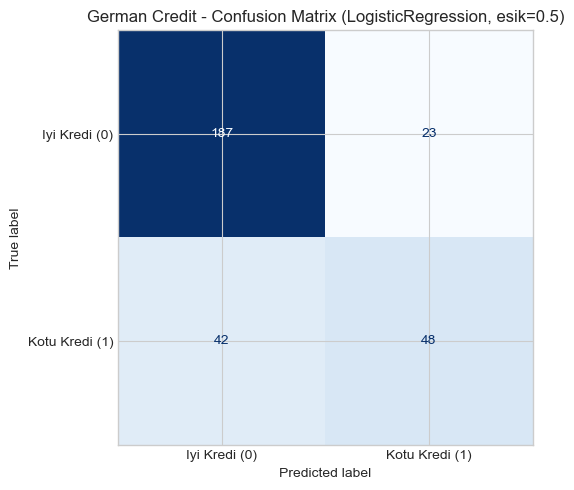


                 Elle  sklearn  Fark
Accuracy       0.7833   0.7833   0.0
Precision      0.6761   0.6761   0.0
Recall         0.5333   0.5333   0.0
Specificity    0.8905   0.8905   0.0
F1             0.5963   0.5963   0.0
F2             0.5568   0.5568   0.0
MCC            0.4569   0.4569   0.0
Balanced Acc.  0.7119   0.7119   0.0
Cohen's Kappa  0.4510   0.4510   0.0

Max mutlak fark (elle vs sklearn): 1.11e-16

YORUM: Naif model (Python 1) accuracy=0.700 verirken, bu model accuracy=0.783 -- gorunuse gore hafif bir iyilesme. Ama recall=0.533: kotu kredilerin sadece %53'ini yakaliyor -- bankanin asil onlemek istedigi hatanin (kotu krediyi onaylamak) yarisindan fazlasi hala kaciyor. Accuracy tek basina bu zayifligi gizliyor; MCC=0.457 (1.0'dan uzak) ve balanced accuracy=0.712 (accuracy'den dusuk) bu zayifligi acikca gosteriyor.

--- classification_report ---
              precision    recall  f1-score   support

   Iyi Kredi       0.82      0.89      0.85       210
  Kotu Kredi       0.

In [4]:
# Confusion Matrix oluştur ve TP, FP, TN, FN değerlerini hesapla
cm = confusion_matrix(yte_cr, pred_lr)
tn, fp, fn, tp = cm.ravel()
print(f"Confusion Matrix (satir=gercek, sutun=tahmin):\n{cm}")
print(f"TP={tp}  FP={fp}  TN={tn}  FN={fn}")

# Confusion Matrix'i görselleştir
fig, ax = plt.subplots(figsize=(5.5, 5))
disp = ConfusionMatrixDisplay(cm, display_labels=["Iyi Kredi (0)", "Kotu Kredi (1)"])
disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
ax.set_title("German Credit - Confusion Matrix (LogisticRegression, esik=0.5)")
plt.tight_layout()
plt.show()

# --- Elle hesaplama ---
acc_manual = (tp + tn) / (tp + tn + fp + fn) # Doğru tahmin / Toplam tahmin
prec_manual = tp / (tp + fp) # Doğru tahmin edilen pozitif / Toplam pozitif tahmin
rec_manual = tp / (tp + fn) # Doğru tahmin edilen pozitif / Toplam gerçek pozitif
spec_manual = tn / (tn + fp) # Doğru tahmin edilen negatif / Toplam gerçek negatif
f1_manual = 2 * prec_manual * rec_manual / (prec_manual + rec_manual) # F1 skoru (recall ve precision'ı eşit ağırlıkla birleştirir)
f2_manual = (1 + 2**2) * prec_manual * rec_manual / (2**2 * prec_manual + rec_manual) # F2 skoru (recall'a daha fazla ağırlık verir)
mcc_manual = (tp * tn - fp * fn) / np.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn)) # Matthews Correlation Coefficient (MCC)
bal_acc_manual = 0.5 * (rec_manual + spec_manual) # Balanced Accuracy (recall ve specificity'yi eşit ağırlıkla birleştirir)

p_o = acc_manual # Gözlenen doğruluk (accuracy)
p_yes = (tp + fp) / (tp + fp + tn + fn) * (tp + fn) / (tp + fp + tn + fn) # Pozitif sınıfın rastgele tahmin edilme olasılığı
p_no = (tn + fn) / (tp + fp + tn + fn) * (tn + fp) / (tp + fp + tn + fn) # Negatif sınıfın rastgele tahmin edilme olasılığı
p_e = p_yes + p_no # Beklenen doğruluk (random chance accuracy)
kappa_manual = (p_o - p_e) / (1 - p_e) # Cohen's Kappa (gözlenen doğruluk ile beklenen doğruluk arasındaki farkı normalize eder)

# --- sklearn ile karsilastirma ---
comparison = pd.DataFrame({
    "Elle": [acc_manual, prec_manual, rec_manual, spec_manual, f1_manual, f2_manual,
             mcc_manual, bal_acc_manual, kappa_manual],
    "sklearn": [
        accuracy_score(yte_cr, pred_lr), precision_score(yte_cr, pred_lr),
        recall_score(yte_cr, pred_lr), tn / (tn + fp),  # specificity'nin dogrudan sklearn fonksiyonu yok
        f1_score(yte_cr, pred_lr), fbeta_score(yte_cr, pred_lr, beta=2),
        matthews_corrcoef(yte_cr, pred_lr), balanced_accuracy_score(yte_cr, pred_lr),
        cohen_kappa_score(yte_cr, pred_lr),
    ],
}, index=["Accuracy", "Precision", "Recall", "Specificity", "F1", "F2", "MCC", "Balanced Acc.", "Cohen's Kappa"])
comparison["Fark"] = (comparison["Elle"] - comparison["sklearn"]).abs()
print(f"\n{comparison.round(4)}")
print(f"\nMax mutlak fark (elle vs sklearn): {comparison['Fark'].max():.2e}")

print(f"\nYORUM: Naif model (Python 1) accuracy=0.700 verirken, bu model accuracy=0.783 -- "
      f"gorunuse gore hafif bir iyilesme. Ama recall={rec_manual:.3f}: kotu kredilerin sadece "
      f"%{100*rec_manual:.0f}'ini yakaliyor -- bankanin asil onlemek istedigi hatanin (kotu krediyi "
      f"onaylamak) yarisindan fazlasi hala kaciyor. Accuracy tek basina bu zayifligi gizliyor; "
      f"MCC={mcc_manual:.3f} (1.0'dan uzak) ve balanced accuracy={bal_acc_manual:.3f} "
      f"(accuracy'den dusuk) bu zayifligi acikca gosteriyor.")

print(f"\n--- classification_report ---\n{classification_report(yte_cr, pred_lr, target_names=['Iyi Kredi','Kotu Kredi'])}")

### 3️⃣ Python 3 - ROC Eğrisi ve AUC (Elle Eşik Taraması + Youden's J)

**Ne yapıyoruz?** Sabit 0.5 eşiğini bir kenara bırakıp modelin ürettiği olasılıkların *tüm* eşik aralığındaki performansına bakıyoruz. Önce ROC eğrisini elle (her benzersiz olasılık değerini eşik olarak deneyip TPR/FPR hesaplayarak) inşa edip `sklearn.roc_curve`/`roc_auc_score` ile doğruluyoruz, sonra Youden's J ile "tek bir karar noktası" seçmemiz gerekseydi hangi eşiği seçeceğimizi buluyoruz.

AUC elle (trapez kurali): 0.801296
AUC sklearn (roc_auc_score): 0.801058
Fark: 2.38e-04

Youden's J en yuksek nokta: esik=0.2467  TPR=0.822  FPR=0.329  J=0.4937
0.5 esiginde  -> recall=0.533  precision=0.676
Youden esiginde -> recall=0.822  precision=0.517


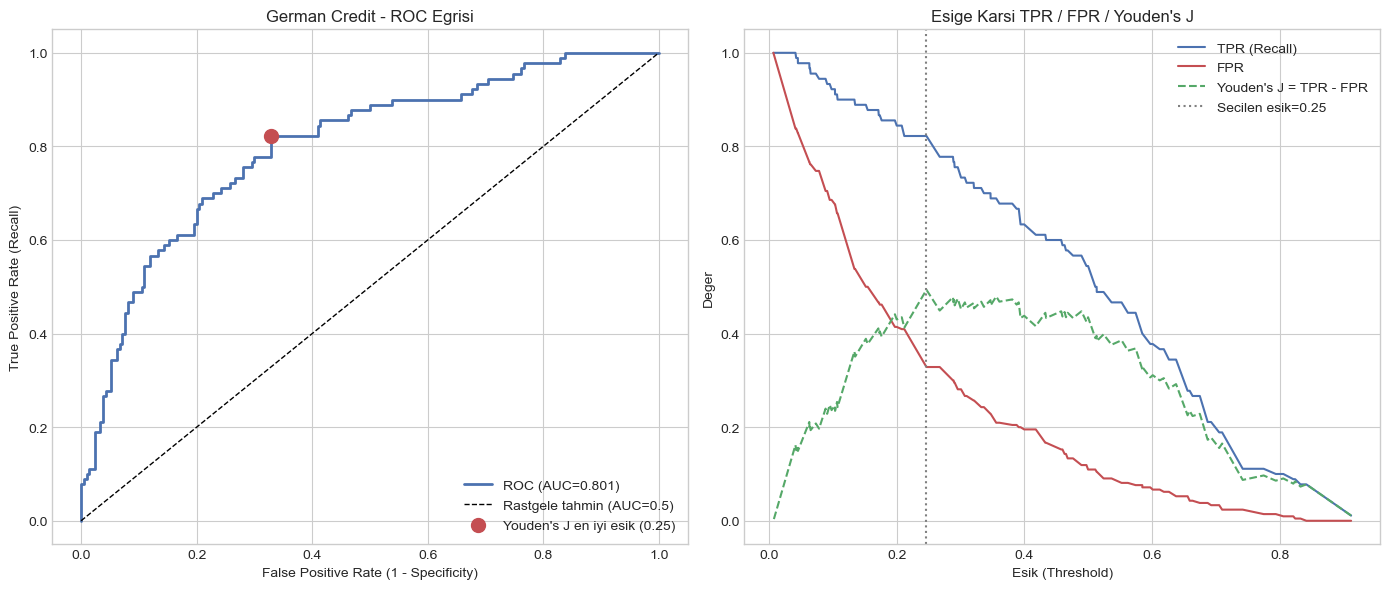


YORUM: AUC=0.801, modelin rastgele bir kotu krediyi rastgele bir iyi krediden daha yuksek skorlama olasiligi ~%80. 0.5 varsayilan esigi, Youden's J'nin onerdigi 0.25 esiginden belirgin sekilde yuksek -- bu da varsayilan esigin bu dengesiz veri setinde recall'u gereksiz yere feda ettigini gosteriyor (Bolum 8'de maliyet asimetrisini de hesaba katan bir esik secimine donecegiz).


In [5]:
# --- Elle ROC insasi ---
thresholds_manual = np.sort(np.unique(proba_lr))[::-1]
P = int((yte_cr == 1).sum())
N = int((yte_cr == 0).sum())
tpr_manual, fpr_manual = [0.0], [0.0]
for t in thresholds_manual:
    pred_t = (proba_lr >= t).astype(int)
    tp_t = int(((pred_t == 1) & (yte_cr == 1)).sum())
    fp_t = int(((pred_t == 1) & (yte_cr == 0)).sum())
    tpr_manual.append(tp_t / P)
    fpr_manual.append(fp_t / N)
tpr_manual.append(1.0)
fpr_manual.append(1.0)
tpr_manual, fpr_manual = np.array(tpr_manual), np.array(fpr_manual)
order = np.argsort(fpr_manual)
auc_manual = np.trapezoid(tpr_manual[order], fpr_manual[order])

# --- sklearn ---
fpr_sk, tpr_sk, thr_sk = roc_curve(yte_cr, proba_lr)
auc_sk = roc_auc_score(yte_cr, proba_lr)
print(f"AUC elle (trapez kurali): {auc_manual:.6f}")
print(f"AUC sklearn (roc_auc_score): {auc_sk:.6f}")
print(f"Fark: {abs(auc_manual - auc_sk):.2e}")

# --- Youden's J ile optimal esik ---
j_scores = tpr_sk - fpr_sk
best_idx = int(np.argmax(j_scores))
best_threshold = thr_sk[best_idx]
print(f"\nYouden's J en yuksek nokta: esik={best_threshold:.4f}  "
      f"TPR={tpr_sk[best_idx]:.3f}  FPR={fpr_sk[best_idx]:.3f}  J={j_scores[best_idx]:.4f}")

pred_youden = (proba_lr >= best_threshold).astype(int)
print(f"0.5 esiginde  -> recall={recall_score(yte_cr, pred_lr):.3f}  precision={precision_score(yte_cr, pred_lr):.3f}")
print(f"Youden esiginde -> recall={recall_score(yte_cr, pred_youden):.3f}  "
      f"precision={precision_score(yte_cr, pred_youden):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].plot(fpr_sk, tpr_sk, color="#4C72B0", lw=2, label=f"ROC (AUC={auc_sk:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=1, label="Rastgele tahmin (AUC=0.5)")
axes[0].scatter(fpr_sk[best_idx], tpr_sk[best_idx], color="#C44E52", s=100, zorder=5,
                 label=f"Youden's J en iyi esik ({best_threshold:.2f})")
axes[0].set_xlabel("False Positive Rate (1 - Specificity)")
axes[0].set_ylabel("True Positive Rate (Recall)")
axes[0].set_title("German Credit - ROC Egrisi")
axes[0].legend(loc="lower right")

axes[1].plot(thr_sk[1:], tpr_sk[1:], label="TPR (Recall)", color="#4C72B0")
axes[1].plot(thr_sk[1:], fpr_sk[1:], label="FPR", color="#C44E52")
axes[1].plot(thr_sk[1:], j_scores[1:], label="Youden's J = TPR - FPR", color="#55A868", linestyle="--")
axes[1].axvline(best_threshold, color="gray", linestyle=":", label=f"Secilen esik={best_threshold:.2f}")
axes[1].set_xlabel("Esik (Threshold)")
axes[1].set_ylabel("Deger")
axes[1].set_title("Esige Karsi TPR / FPR / Youden's J")
axes[1].legend()
plt.tight_layout()
plt.show()

print(f"\nYORUM: AUC={auc_sk:.3f}, modelin rastgele bir kotu krediyi rastgele bir iyi krediden "
      f"daha yuksek skorlama olasiligi ~%{100*auc_sk:.0f}. 0.5 varsayilan esigi, Youden's J'nin "
      f"onerdigi {best_threshold:.2f} esiginden belirgin sekilde yuksek -- bu da varsayilan esigin "
      f"bu dengesiz veri setinde recall'u gereksiz yere feda ettigini gosteriyor (Bolum 8'de maliyet "
      f"asimetrisini de hesaba katan bir esik secimine donecegiz).")

### 4️⃣ Python 4 - Precision-Recall Eğrisi, Average Precision ve Dengesizlik Deneyi

**Ne yapıyoruz?** Önce PR eğrisini ve AP'yi normal test setinde çiziyoruz. Sonra Bölüm 4'teki iddiayı somut olarak test ediyoruz: test setindeki pozitif (kötü kredi) örnekleri kademeli olarak azaltıp (aynı modelin aynı skorlarını kullanarak, yalnızca hangi örneklerin test setinde kaldığını değiştirerek) dengesizlik arttıkça **ROC-AUC'nin nispeten sabit kalırken AP'nin çökmesini** gözlemliyoruz.

Average Precision: 0.6447  |  Rastgele model baseline (pozitif sinif orani): 0.3000


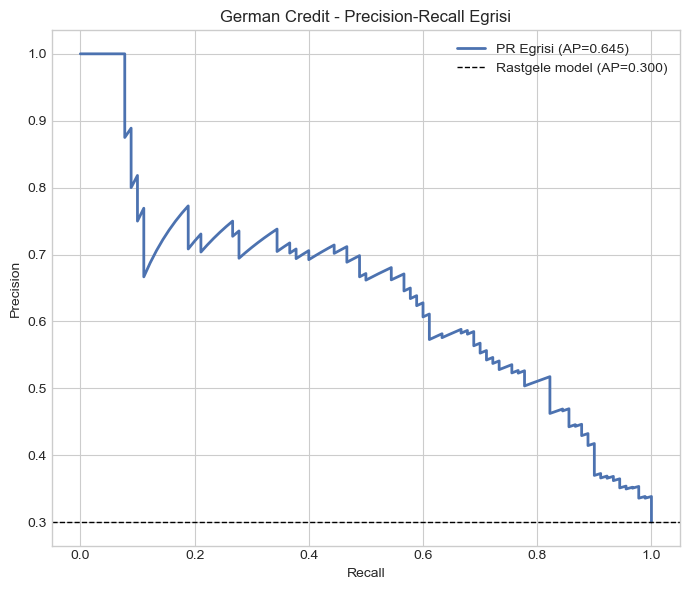


   Pozitif Tutma Orani  Pozitif Sinif Orani  ROC-AUC  Average Precision
0                  1.0                0.300    0.801              0.645
1                  0.5                0.176    0.766              0.460
2                  0.3                0.114    0.767              0.349
3                  0.2                0.079    0.760              0.338
4                  0.1                0.041    0.768              0.389


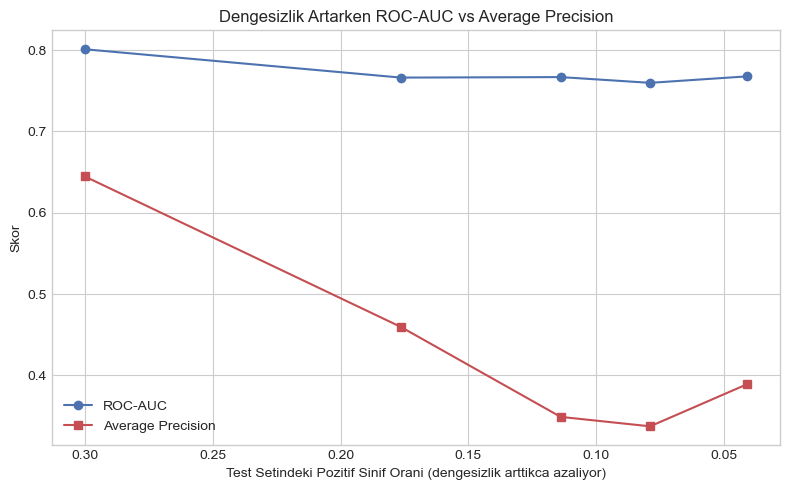


YORUM: Pozitif sinif orani %30'den %4'e dusurulurken ROC-AUC 0.80'den 0.77'e (goreceli olarak az degisti), AP ise 0.64'den 0.39'e cakildi -- ve AP'nin dususu byuk olcude pozitif sinif oranindaki dususu takip ediyor. Bu, Bolum 4'teki iddiayi dogruluyor: ayni model, ayni skorlarla, sadece test setindeki denge degistiginde ROC-AUC 'yanlisligi gizleyebilirken' AP durumun gercek zorlugunu daha durust yansitiyor.


In [6]:
prec_c, rec_c, thr_c = precision_recall_curve(yte_cr, proba_lr)
ap = average_precision_score(yte_cr, proba_lr)
baseline_ap = yte_cr.mean()
print(f"Average Precision: {ap:.4f}  |  Rastgele model baseline (pozitif sinif orani): {baseline_ap:.4f}")

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(rec_c, prec_c, color="#4C72B0", lw=2, label=f"PR Egrisi (AP={ap:.3f})")
ax.axhline(baseline_ap, color="k", linestyle="--", lw=1, label=f"Rastgele model (AP={baseline_ap:.3f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("German Credit - Precision-Recall Egrisi")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

# --- Dengesizlik deneyi: pozitif sinifi kademeli azaltip AUC vs AP'yi karsilastir ---
rng = np.random.RandomState(RANDOM_STATE)
pos_idx_all = np.where(yte_cr.values == 1)[0]
neg_idx_all = np.where(yte_cr.values == 0)[0]

experiment_rows = []
for keep_frac in [1.0, 0.5, 0.3, 0.2, 0.1]:
    n_keep = max(1, int(len(pos_idx_all) * keep_frac))
    keep_pos = rng.choice(pos_idx_all, size=n_keep, replace=False)
    idx = np.concatenate([keep_pos, neg_idx_all])
    y_sub, p_sub = yte_cr.values[idx], proba_lr[idx]
    experiment_rows.append({
        "Pozitif Tutma Orani": keep_frac,
        "Pozitif Sinif Orani": y_sub.mean(),
        "ROC-AUC": roc_auc_score(y_sub, p_sub),
        "Average Precision": average_precision_score(y_sub, p_sub),
    })
df_exp = pd.DataFrame(experiment_rows)
print(f"\n{df_exp.round(3)}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(df_exp["Pozitif Sinif Orani"], df_exp["ROC-AUC"], marker="o", label="ROC-AUC", color="#4C72B0")
ax.plot(df_exp["Pozitif Sinif Orani"], df_exp["Average Precision"], marker="s", label="Average Precision", color="#C44E52")
ax.set_xlabel("Test Setindeki Pozitif Sinif Orani (dengesizlik arttikca azaliyor)")
ax.set_ylabel("Skor")
ax.set_title("Dengesizlik Artarken ROC-AUC vs Average Precision")
ax.invert_xaxis()
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nYORUM: Pozitif sinif orani %{100*df_exp['Pozitif Sinif Orani'].iloc[0]:.0f}'den "
      f"%{100*df_exp['Pozitif Sinif Orani'].iloc[-1]:.0f}'e dusurulurken ROC-AUC "
      f"{df_exp['ROC-AUC'].iloc[0]:.2f}'den {df_exp['ROC-AUC'].iloc[-1]:.2f}'e (goreceli olarak az degisti), "
      f"AP ise {df_exp['Average Precision'].iloc[0]:.2f}'den {df_exp['Average Precision'].iloc[-1]:.2f}'e "
      f"cakildi -- ve AP'nin dususu byuk olcude pozitif sinif oranindaki dususu takip ediyor. Bu, Bolum 4'teki "
      f"iddiayi dogruluyor: ayni model, ayni skorlarla, sadece test setindeki denge degistiginde ROC-AUC "
      f"'yanlisligi gizleyebilirken' AP durumun gercek zorlugunu daha durust yansitiyor.")

### 5️⃣ Python 5 - Kalibrasyon Eğrisi ve Brier Skoru: İyi vs Kötü Kalibre Modeller

**Ne yapıyoruz?** `LogisticRegression`'ı (log-loss'u doğrudan optimize ettiği için doğası gereği iyi kalibre) `GaussianNB` (koşullu bağımsızlık varsayımı yüzünden klasik olarak aşırı özgüvenli, Niculescu-Mizil & Caruana 2005) ile karşılaştırıyoruz. Reliability diagram'lar ve Brier skorlarıyla farkı gösterip, `CalibratedClassifierCV` (hem Platt/sigmoid hem isotonic) ile `GaussianNB`'yi düzeltiyoruz.

Brier Skoru - LogisticRegression: 0.1574
Brier Skoru - GaussianNB (ham):   0.2668

GaussianNB olasilik dagilimi (percentile'lar): [0.00000e+00 1.00000e-06 1.19066e-01 9.99997e-01 1.00000e+00]
-> GaussianNB, gercekte belirsiz oldugu ornekler icin bile 0'a ya da 1'e cok yakin olasiliklar uretiyor (asiri ozguven) -- kosullu bagimsizlik varsayiminin tipik bir sonucu.


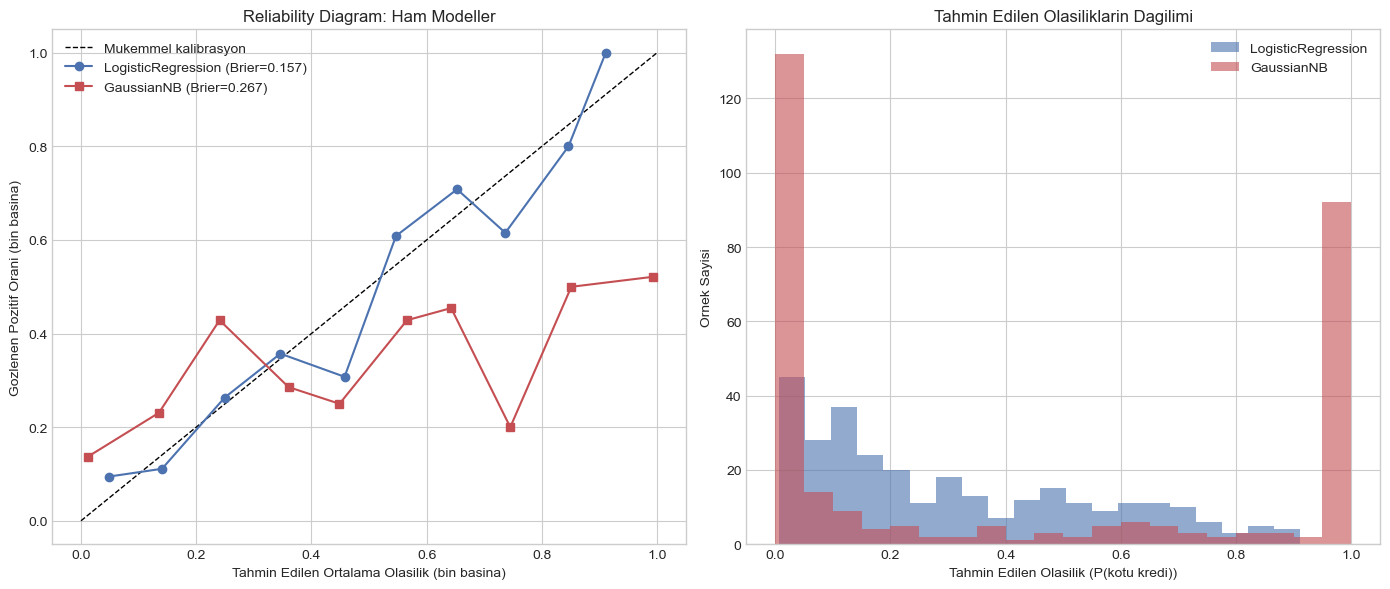


                           Model  Brier Skoru  Iyilesme (ham'a gore)
0               GaussianNB (ham)       0.2668                 0.0000
1     GaussianNB + Platt/Sigmoid       0.1805                32.3371
2          GaussianNB + Isotonic       0.1824                31.6173
3  LogisticRegression (referans)       0.1574                41.0035


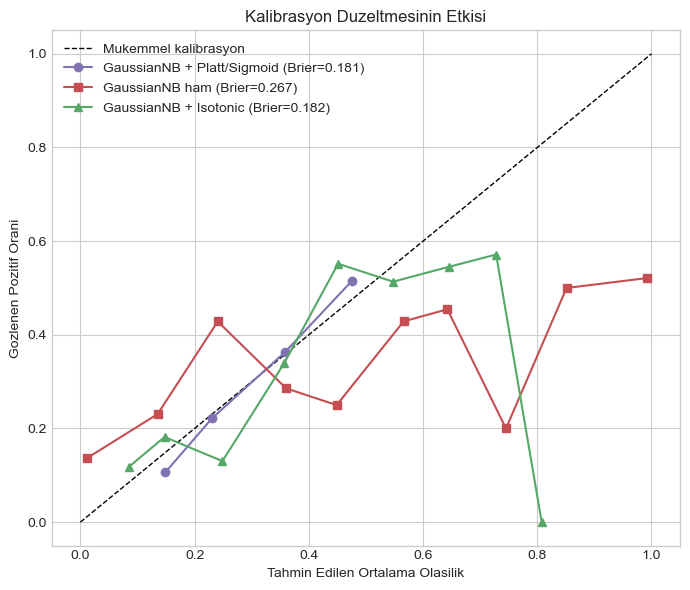


YORUM: GaussianNB'nin Brier skoru (0.267), LogisticRegression'inkinden (0.157) belirgin sekilde kotu -- olasiliklar 0/1'e asiri yakin urettigi icin. Isotonic kalibrasyon Brier skorunu %32 iyilestirip LogisticRegression'a yaklastiriyor. Onemli nokta: kalibrasyon, modelin SIRALAMA gucunu (AUC'yi) degistirmez -- sadece urettigi olasiliklarin anlamini duzeltir; bu yuzden bir kredi skorlama sisteminde 'skor sirasi dogru ama fiyatlama icin kullanilan olasilik yanlis' durumunu cozer.


In [8]:
nb_credit = GaussianNB()
nb_credit.fit(Xtr_cr_t, ytr_cr)
proba_nb = nb_credit.predict_proba(Xte_cr_t)[:, 1]

brier_lr = brier_score_loss(yte_cr, proba_lr)
brier_nb = brier_score_loss(yte_cr, proba_nb)
print(f"Brier Skoru - LogisticRegression: {brier_lr:.4f}")
print(f"Brier Skoru - GaussianNB (ham):   {brier_nb:.4f}")
print(f"\nGaussianNB olasilik dagilimi (percentile'lar): "
      f"{np.percentile(proba_nb, [0, 10, 50, 90, 100]).round(6)}")
print("-> GaussianNB, gercekte belirsiz oldugu ornekler icin bile 0'a ya da 1'e cok yakin "
      "olasiliklar uretiyor (asiri ozguven) -- kosullu bagimsizlik varsayiminin tipik bir sonucu.")

frac_pos_lr, mean_pred_lr = calibration_curve(yte_cr, proba_lr, n_bins=10)
frac_pos_nb, mean_pred_nb = calibration_curve(yte_cr, proba_nb, n_bins=10)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].plot([0, 1], [0, 1], "k--", lw=1, label="Mukemmel kalibrasyon")
axes[0].plot(mean_pred_lr, frac_pos_lr, marker="o", color="#4C72B0", label=f"LogisticRegression (Brier={brier_lr:.3f})")
axes[0].plot(mean_pred_nb, frac_pos_nb, marker="s", color="#C44E52", label=f"GaussianNB (Brier={brier_nb:.3f})")
axes[0].set_xlabel("Tahmin Edilen Ortalama Olasilik (bin basina)")
axes[0].set_ylabel("Gozlenen Pozitif Orani (bin basina)")
axes[0].set_title("Reliability Diagram: Ham Modeller")
axes[0].legend()

axes[1].hist(proba_lr, bins=20, alpha=0.6, label="LogisticRegression", color="#4C72B0")
axes[1].hist(proba_nb, bins=20, alpha=0.6, label="GaussianNB", color="#C44E52")
axes[1].set_xlabel("Tahmin Edilen Olasilik (P(kotu kredi))")
axes[1].set_ylabel("Ornek Sayisi")
axes[1].set_title("Tahmin Edilen Olasiliklarin Dagilimi")
axes[1].legend()
plt.tight_layout()
plt.show()

# --- Kalibrasyon duzeltmesi: Platt (sigmoid) ve isotonic ---
cal_nb_sigmoid = CalibratedClassifierCV(GaussianNB(), method="sigmoid", cv=5)
cal_nb_sigmoid.fit(Xtr_cr_t, ytr_cr)
proba_nb_sigmoid = cal_nb_sigmoid.predict_proba(Xte_cr_t)[:, 1]

cal_nb_isotonic = CalibratedClassifierCV(GaussianNB(), method="isotonic", cv=5)
cal_nb_isotonic.fit(Xtr_cr_t, ytr_cr)
proba_nb_isotonic = cal_nb_isotonic.predict_proba(Xte_cr_t)[:, 1]

brier_nb_sigmoid = brier_score_loss(yte_cr, proba_nb_sigmoid)
brier_nb_isotonic = brier_score_loss(yte_cr, proba_nb_isotonic)

brier_table = pd.DataFrame({
    "Model": ["GaussianNB (ham)", "GaussianNB + Platt/Sigmoid", "GaussianNB + Isotonic", "LogisticRegression (referans)"],
    "Brier Skoru": [brier_nb, brier_nb_sigmoid, brier_nb_isotonic, brier_lr],
})
brier_table["Iyilesme (ham'a gore)"] = (brier_nb - brier_table["Brier Skoru"]) / brier_nb * 100
print(f"\n{brier_table.round(4)}")

frac_pos_cal, mean_pred_cal = calibration_curve(yte_cr, proba_nb_isotonic, n_bins=10)
frac_pos_cal_sigmoid, mean_pred_cal_sigmoid = calibration_curve(yte_cr, proba_nb_sigmoid, n_bins=10)
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Mukemmel kalibrasyon")
ax.plot(mean_pred_cal_sigmoid, frac_pos_cal_sigmoid, marker="o", color="#8172B2", label=f"GaussianNB + Platt/Sigmoid (Brier={brier_nb_sigmoid:.3f})")
ax.plot(mean_pred_nb, frac_pos_nb, marker="s", color="#C44E52", label=f"GaussianNB ham (Brier={brier_nb:.3f})")
ax.plot(mean_pred_cal, frac_pos_cal, marker="^", color="#55A868", label=f"GaussianNB + Isotonic (Brier={brier_nb_isotonic:.3f})")
ax.set_xlabel("Tahmin Edilen Ortalama Olasilik")
ax.set_ylabel("Gozlenen Pozitif Orani")
ax.set_title("Kalibrasyon Duzeltmesinin Etkisi")
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nYORUM: GaussianNB'nin Brier skoru ({brier_nb:.3f}), LogisticRegression'inkinden "
      f"({brier_lr:.3f}) belirgin sekilde kotu -- olasiliklar 0/1'e asiri yakin urettigi icin. "
      f"Isotonic kalibrasyon Brier skorunu %{100*(brier_nb-brier_nb_isotonic)/brier_nb:.0f} iyilestirip "
      f"LogisticRegression'a yaklastiriyor. Onemli nokta: kalibrasyon, modelin SIRALAMA gucunu "
      f"(AUC'yi) degistirmez -- sadece urettigi olasiliklarin anlamini duzeltir; bu yuzden bir kredi "
      f"skorlama sisteminde 'skor sirasi dogru ama fiyatlama icin kullanilan olasilik yanlis' durumunu "
      f"cozer.")

### 6️⃣ Python 6 - Veri Hazırlama: Ecoli (UCI, Protein Lokalizasyon Sınıflandırması)

**Ne yapıyoruz?** Nakai & Kanehisa (1991)'in klasik biyoinformatik veri setini yüklüyoruz — 336 protein, 7 sayısal özellik (sinyal peptidi/membran skorları), 8 sınıflı hedef (proteinin hücre içindeki lokalizasyonu: `cp`=sitoplazma, `im`=iç membran, `pp`=periplazma, vb.). **Bu veri seti kasıtlı seçildi çünkü Bölüm 5'teki macro/micro/weighted ayrımını göstermek için ideal ölçüde dengesiz:** en büyük sınıf (`cp`) 143 örnekle temsil edilirken en küçük iki sınıf (`imL`, `imS`) sadece 2'şer örnekle temsil ediliyor. Bu iki mikro-sınıfı, güvenilir bir eğitim/test bölünmesi (stratified split) yapabilmek için `imLS` adında tek bir sınıfta birleştiriyoruz -- **bu, aşırı nadir sınıflarla karşılaşıldığında gerçek projelerde sık kullanılan, dürüstçe belirtilmesi gereken bir ön işleme kararıdır.**

In [10]:
ECOLI_COLS = ["mcg", "gvh", "lip", "chg", "aac", "alm1", "alm2", "localization"]
df_ecoli = pd.read_csv(
    "https://raw.githubusercontent.com/jbrownlee/Datasets/master/ecoli.csv",
    header=None, names=ECOLI_COLS,
)
print("Birlestirmeden once sinif dagilimi:")
print(df_ecoli["localization"].value_counts())

# imL (2 ornek) ve imS (2 ornek) -> guvenilir stratified split icin tek sinifta birlestir
df_ecoli["localization"] = df_ecoli["localization"].replace({"imL": "imLS", "imS": "imLS"})
print("\nBirlestirmeden sonra (imL + imS -> imLS):")
print(df_ecoli["localization"].value_counts())

X_ecoli = df_ecoli.drop(columns="localization")
y_ecoli = df_ecoli["localization"]
Xtr_ec, Xte_ec, ytr_ec, yte_ec = train_test_split(
    X_ecoli, y_ecoli, test_size=0.25, random_state=RANDOM_STATE, stratify=y_ecoli
)
print(f"\nEgitim: {Xtr_ec.shape[0]} | Test: {Xte_ec.shape[0]}")
print(f"\nTest setindeki sinif dagilimi (en kucuk sinif dikkat!):")
print(yte_ec.value_counts())

ecoli_scaler = StandardScaler()
Xtr_ec_s = ecoli_scaler.fit_transform(Xtr_ec)
Xte_ec_s = ecoli_scaler.transform(Xte_ec)

ECOLI_LABELS = sorted(y_ecoli.unique())
clf_ecoli = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
clf_ecoli.fit(Xtr_ec_s, ytr_ec)
pred_ecoli = clf_ecoli.predict(Xte_ec_s)
print(f"\nGenel accuracy: {accuracy_score(yte_ec, pred_ecoli):.4f}")

Birlestirmeden once sinif dagilimi:
localization
cp     143
im      77
pp      52
imU     35
om      20
omL      5
imS      2
imL      2
Name: count, dtype: int64

Birlestirmeden sonra (imL + imS -> imLS):
localization
cp      143
im       77
pp       52
imU      35
om       20
omL       5
imLS      4
Name: count, dtype: int64

Egitim: 252 | Test: 84

Test setindeki sinif dagilimi (en kucuk sinif dikkat!):
localization
cp      36
im      19
pp      13
imU      9
om       5
imLS     1
omL      1
Name: count, dtype: int64

Genel accuracy: 0.8810


### 7️⃣ Python 7 - Çok Sınıflı Confusion Matrix ve Sınıf Başı Metrikler

**Ne yapıyoruz?** 7x7 confusion matrix'i görselleştirip her sınıf için ayrı ayrı precision/recall/F1'i (`classification_report` ile) inceliyoruz — genel accuracy'nin tek başına neyi gizlediğini sınıf bazında görmek için.

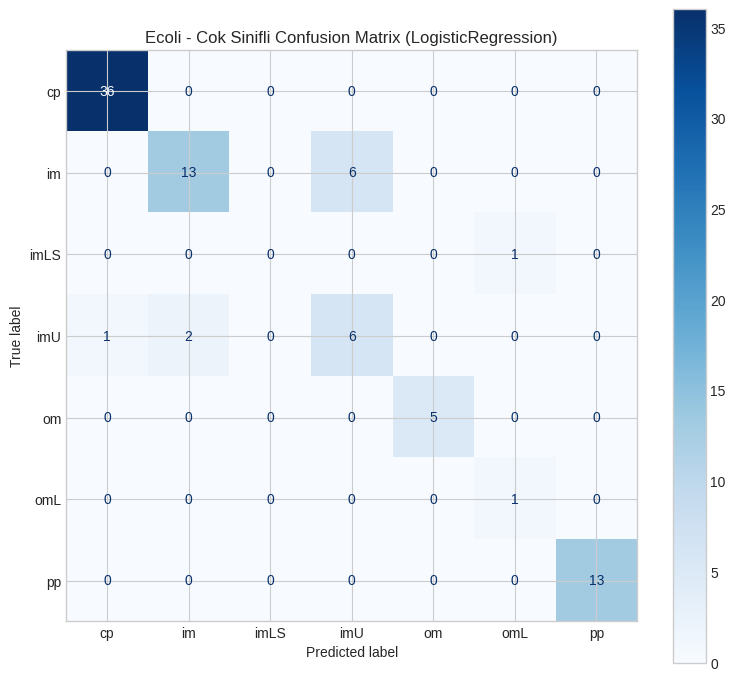

              precision    recall  f1-score   support

          cp       0.97      1.00      0.99        36
          im       0.87      0.68      0.76        19
        imLS       0.00      0.00      0.00         1
         imU       0.50      0.67      0.57         9
          om       1.00      1.00      1.00         5
         omL       0.50      1.00      0.67         1
          pp       1.00      1.00      1.00        13

    accuracy                           0.88        84
   macro avg       0.69      0.76      0.71        84
weighted avg       0.89      0.88      0.88        84


  Sinif     F1  Test Ornek Sayisi (Support)
0    cp  0.986                           36
1    im  0.765                           19
2  imLS  0.000                            1
3   imU  0.571                            9
4    om  1.000                            5
5   omL  0.667                            1
6    pp  1.000                           13

YORUM: En kotu performans 'imLS' sinifinda (F1=0.

In [8]:
cm_ecoli = confusion_matrix(yte_ec, pred_ecoli, labels=ECOLI_LABELS)

fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(cm_ecoli, display_labels=ECOLI_LABELS)
disp.plot(ax=ax, cmap="Blues", colorbar=True, values_format="d")
ax.set_title("Ecoli - Cok Sinifli Confusion Matrix (LogisticRegression)")
plt.tight_layout()
plt.show()

print(classification_report(yte_ec, pred_ecoli, labels=ECOLI_LABELS, zero_division=0))

per_class_f1 = f1_score(yte_ec, pred_ecoli, average=None, labels=ECOLI_LABELS, zero_division=0)
support = yte_ec.value_counts().reindex(ECOLI_LABELS).fillna(0).astype(int)
df_per_class = pd.DataFrame({"Sinif": ECOLI_LABELS, "F1": per_class_f1, "Test Ornek Sayisi (Support)": support.values})
print(f"\n{df_per_class.round(3)}")

worst = df_per_class.loc[df_per_class["F1"].idxmin()]
print(f"\nYORUM: En kotu performans '{worst['Sinif']}' sinifinda (F1={worst['F1']:.2f}, sadece "
      f"{int(worst['Test Ornek Sayisi (Support)'])} test ornegi var) -- confusion matrix'te bu satirin "
      f"nereye 'kaydigina' bakarak modelin bu nadir sinifi hangi cogunluk sinifiyla karistirdigini "
      f"gorebiliriz. Genel accuracy bu basarisizligi neredeyse tamamen gizliyor cunku bu sinif test "
      f"setinin kucuk bir kismini olusturuyor -- Bolum 8'de bunu sayisal olarak kesinlestirecegiz.")

### 8️⃣ Python 8 - Macro vs Micro vs Weighted F1 (Elle + `sklearn`)

**Ne yapıyoruz?** Bölüm 5'teki üç formülü elle hesaplayıp `sklearn` ile doğruluyoruz, ve üçünün Ecoli'de NEDEN bu kadar farklı sonuç verdiğini sayısal olarak gösteriyoruz.

               Elle  sklearn  Fark
Macro-F1     0.7127   0.7127   0.0
Micro-F1     0.8810   0.8810   0.0
Weighted-F1  0.8791   0.8791   0.0

Not: Micro-F1 (0.8810) ile accuracy (0.8810) cok sinifli/tek-etiketli siniflandirmada matematiksel olarak birbirine esittir.


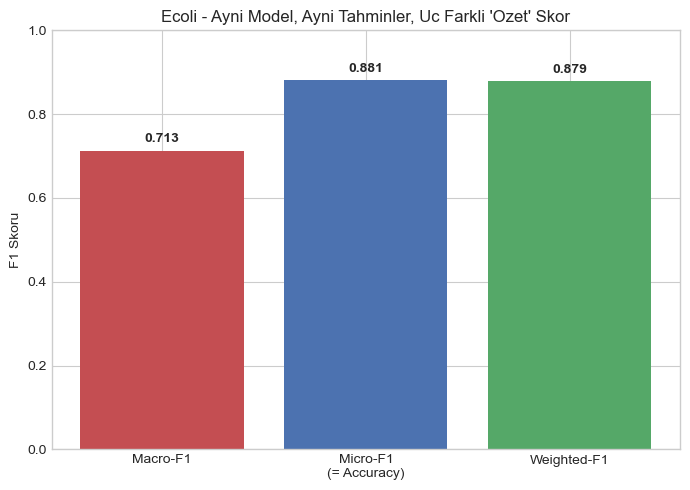


YORUM: Ayni model, ayni test seti tahminleriyle Macro-F1=0.713 ile Micro-F1=0.881 arasinda 0.168'lik bir fark var. Bu fark TAMAMEN sinif dengesizliginden kaynaklaniyor: nadir siniflardaki (orn. 'imLS', 'omL') kotu performans macro ortalamada tam agirlikla sayilirken, micro'da bu siniflarin az sayidaki orneği toplam icinde kayboluyor. Eger is bagalminda her lokalizasyon sinifini esit onemde gormeniz gerekiyorsa (orn. nadir bir hastalik alt-tipini kacirmamak kritikse) sadece Micro-F1/accuracy raporlamak yanlis bir guven verebilir -- Macro-F1'in daha dusuk olmasi asil 'gercek' zorlugu gosteriyor.


In [11]:
# --- Elle hesaplama ---
f1_per_class_manual = f1_score(yte_ec, pred_ecoli, average=None, labels=ECOLI_LABELS, zero_division=0)
support_per_class = yte_ec.value_counts().reindex(ECOLI_LABELS).fillna(0).values
n_total = support_per_class.sum()

macro_f1_manual = f1_per_class_manual.mean()
weighted_f1_manual = np.sum(f1_per_class_manual * support_per_class) / n_total

# Micro-average: tum TP/FP/FN'leri once topla, sonra tek f1 hesapla
tp_total = fp_total = fn_total = 0
for lbl in ECOLI_LABELS:
    tp_l = int(((pred_ecoli == lbl) & (yte_ec == lbl)).sum())
    fp_l = int(((pred_ecoli == lbl) & (yte_ec != lbl)).sum())
    fn_l = int(((pred_ecoli != lbl) & (yte_ec == lbl)).sum())
    tp_total += tp_l; fp_total += fp_l; fn_total += fn_l
micro_prec = tp_total / (tp_total + fp_total)
micro_rec = tp_total / (tp_total + fn_total)
micro_f1_manual = 2 * micro_prec * micro_rec / (micro_prec + micro_rec)

# --- sklearn ---
comparison_avg = pd.DataFrame({
    "Elle": [macro_f1_manual, micro_f1_manual, weighted_f1_manual],
    "sklearn": [
        f1_score(yte_ec, pred_ecoli, average="macro", zero_division=0),
        f1_score(yte_ec, pred_ecoli, average="micro", zero_division=0),
        f1_score(yte_ec, pred_ecoli, average="weighted", zero_division=0),
    ],
}, index=["Macro-F1", "Micro-F1", "Weighted-F1"])
comparison_avg["Fark"] = (comparison_avg["Elle"] - comparison_avg["sklearn"]).abs()
print(comparison_avg.round(4))
print(f"\nNot: Micro-F1 ({micro_f1_manual:.4f}) ile accuracy ({accuracy_score(yte_ec, pred_ecoli):.4f}) "
      f"cok sinifli/tek-etiketli siniflandirmada matematiksel olarak birbirine esittir.")

fig, ax = plt.subplots(figsize=(7, 5))
avg_names = ["Macro-F1", "Micro-F1\n(= Accuracy)", "Weighted-F1"]
avg_values = [macro_f1_manual, micro_f1_manual, weighted_f1_manual]
bars = ax.bar(avg_names, avg_values, color=["#C44E52", "#4C72B0", "#55A868"])
ax.set_ylim(0, 1)
ax.set_ylabel("F1 Skoru")
ax.set_title("Ecoli - Ayni Model, Ayni Tahminler, Uc Farkli 'Ozet' Skor")
for bar, val in zip(bars, avg_values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f"{val:.3f}", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\nYORUM: Ayni model, ayni test seti tahminleriyle Macro-F1={macro_f1_manual:.3f} ile "
      f"Micro-F1={micro_f1_manual:.3f} arasinda {abs(micro_f1_manual-macro_f1_manual):.3f}'lik bir fark var. "
      f"Bu fark TAMAMEN sinif dengesizliginden kaynaklaniyor: nadir siniflardaki (orn. 'imLS', 'omL') "
      f"kotu performans macro ortalamada tam agirlikla sayilirken, micro'da bu siniflarin az sayidaki "
      f"orneği toplam icinde kayboluyor. Eger is bagalminda her lokalizasyon sinifini esit onemde "
      f"gormeniz gerekiyorsa (orn. nadir bir hastalik alt-tipini kacirmamak kritikse) sadece Micro-F1/"
      f"accuracy raporlamak yanlis bir guven verebilir -- Macro-F1'in daha dusuk olmasi asil "
      f"'gercek' zorlugu gosteriyor.")

### 9️⃣ Python 9 - Çok Sınıflı ROC/AUC (One-vs-Rest)

**Ne yapıyoruz?** Her sınıf için "bu sınıf mı, değil mi" ikili ROC eğrisini çizip, `roc_auc_score(multi_class='ovr')` ile macro/weighted AUC'yi hesaplıyoruz.

AUC (One-vs-Rest, macro):    0.9748
AUC (One-vs-Rest, weighted): 0.9778


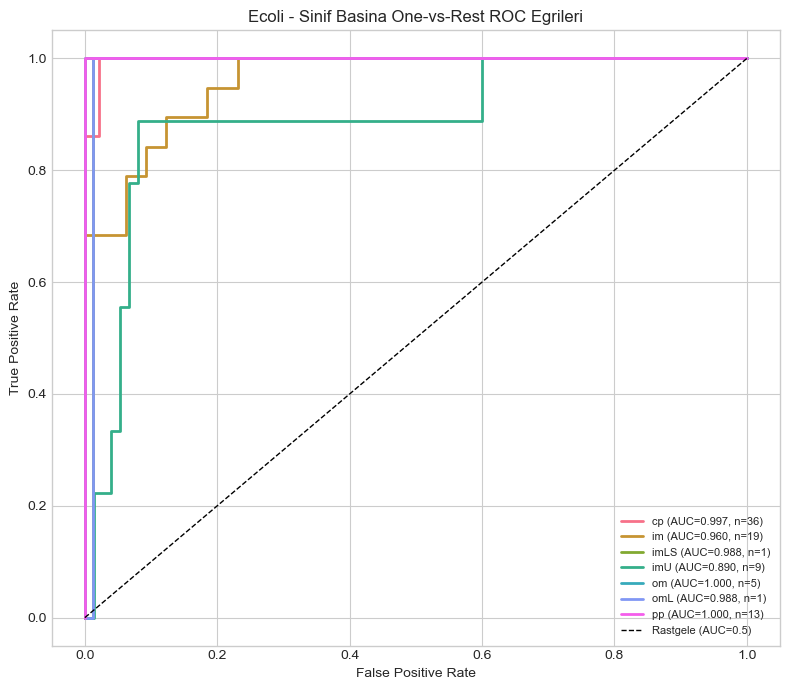


YORUM: Macro AUC (0.975) ile Weighted AUC (0.978) arasindaki fark F1'dekinden daha kucuk -- cunku AUC, tahmin edilen SIRALAMA kalitesini olcuyor ve nadir siniflar icin bile model cogunlukla dogru bir olasilik sirasi uretebiliyor (F1 ise sabit bir esikte 'karar' kalitesini olctugu icin nadir siniflarda daha sert cezalandiriyor). En dusuk sinif-bazli AUC 'imU' sinifinda (0.890) -- bu, F1'de en kotu performans gosteren sinifla ayni ya da yakin olabilir, iki metrigin farkli acilardan ayni zayifligi dogruladigini gosteriyor.


In [12]:
proba_ecoli = clf_ecoli.predict_proba(Xte_ec_s)

auc_ovr_macro = roc_auc_score(yte_ec, proba_ecoli, multi_class="ovr", average="macro", labels=clf_ecoli.classes_)
auc_ovr_weighted = roc_auc_score(yte_ec, proba_ecoli, multi_class="ovr", average="weighted", labels=clf_ecoli.classes_)
print(f"AUC (One-vs-Rest, macro):    {auc_ovr_macro:.4f}")
print(f"AUC (One-vs-Rest, weighted): {auc_ovr_weighted:.4f}")

fig, ax = plt.subplots(figsize=(8, 7))
class_to_col = {lbl: i for i, lbl in enumerate(clf_ecoli.classes_)}
colors = sns.color_palette("husl", len(ECOLI_LABELS))
per_class_auc = {}
for lbl, color in zip(ECOLI_LABELS, colors):
    y_bin = (yte_ec == lbl).astype(int)
    col_idx = class_to_col[lbl]
    fpr_l, tpr_l, _ = roc_curve(y_bin, proba_ecoli[:, col_idx])
    class_auc = roc_auc_score(y_bin, proba_ecoli[:, col_idx])
    per_class_auc[lbl] = class_auc
    ax.plot(fpr_l, tpr_l, color=color, lw=2, label=f"{lbl} (AUC={class_auc:.3f}, n={int((yte_ec==lbl).sum())})")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Rastgele (AUC=0.5)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Ecoli - Sinif Basina One-vs-Rest ROC Egrileri")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

worst_auc_class = min(per_class_auc, key=per_class_auc.get)
print(f"\nYORUM: Macro AUC ({auc_ovr_macro:.3f}) ile Weighted AUC ({auc_ovr_weighted:.3f}) arasindaki "
      f"fark F1'dekinden daha kucuk -- cunku AUC, tahmin edilen SIRALAMA kalitesini olcuyor ve nadir "
      f"siniflar icin bile model cogunlukla dogru bir olasilik sirasi uretebiliyor (F1 ise sabit bir "
      f"esikte 'karar' kalitesini olctugu icin nadir siniflarda daha sert cezalandiriyor). En dusuk "
      f"sinif-bazli AUC '{worst_auc_class}' sinifinda ({per_class_auc[worst_auc_class]:.3f}) -- bu, "
      f"F1'de en kotu performans gosteren sinifla ayni ya da yakin olabilir, iki metrigin farkli "
      f"acilardan ayni zayifligi dogruladigini gosteriyor.")

### 🔟 Python 10 - Veri Hazırlama: Boston Housing (UCI, Konut Fiyatı Regresyonu)

**Ne yapıyoruz?** Harrison & Rubinfeld (1978)'in klasik konut fiyatı veri setini yüklüyoruz — Boston bölgesinde 506 mahalle, 13 özellik (suç oranı, oda sayısı, öğrenci/öğretmen oranı, vb.), hedef `MEDV` (medyan konut fiyatı, binlerce dolar, 5.0-50.0 aralığında — **sıfıra hiç yaklaşmıyor**, bu da onu MAPE hesaplamak için güvenli bir hedef yapıyor).

In [13]:
BOSTON_COLS = ["CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE", "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT", "MEDV"]
df_boston = pd.read_csv(
    "https://raw.githubusercontent.com/jbrownlee/Datasets/master/housing.csv",
    header=None, names=BOSTON_COLS,
)
print(f"Boyut: {df_boston.shape}")
print(f"MEDV (hedef, bin dolar) araligi: [{df_boston['MEDV'].min():.1f}, {df_boston['MEDV'].max():.1f}], "
      f"ortalama: {df_boston['MEDV'].mean():.1f}")
print(f"Sifira yakin/esit MEDV sayisi: {(df_boston['MEDV'] <= 1).sum()}  (MAPE icin guvenli)")

X_boston = df_boston.drop(columns="MEDV")
y_boston = df_boston["MEDV"]
Xtr_bo, Xte_bo, ytr_bo, yte_bo = train_test_split(X_boston, y_boston, test_size=0.25, random_state=RANDOM_STATE)
print(f"\nEgitim: {Xtr_bo.shape[0]} | Test: {Xte_bo.shape[0]}")

boston_scaler = StandardScaler()
Xtr_bo_s = boston_scaler.fit_transform(Xtr_bo)
Xte_bo_s = boston_scaler.transform(Xte_bo)

linreg_boston = LinearRegression()
linreg_boston.fit(Xtr_bo_s, ytr_bo)
pred_boston_lr = linreg_boston.predict(Xte_bo_s)

rf_boston = RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE)
rf_boston.fit(Xtr_bo_s, ytr_bo)
pred_boston_rf = rf_boston.predict(Xte_bo_s)

print(f"\nLinearRegression R2: {r2_score(yte_bo, pred_boston_lr):.4f}")
print(f"RandomForestRegressor R2: {r2_score(yte_bo, pred_boston_rf):.4f}")

Boyut: (506, 14)
MEDV (hedef, bin dolar) araligi: [5.0, 50.0], ortalama: 22.5
Sifira yakin/esit MEDV sayisi: 0  (MAPE icin guvenli)

Egitim: 379 | Test: 127

LinearRegression R2: 0.6844
RandomForestRegressor R2: 0.8591


### 1️⃣1️⃣ Python 11 - Regresyon Metrikleri (Elle + `sklearn`) ve Aykırı Değer Duyarlılığı

**Ne yapıyoruz?** `LinearRegression` tahminlerinden Bölüm 7'deki tüm regresyon metriklerini (MAE, MSE, RMSE, MAPE, Median AE, Max Error, R², Adjusted R², Explained Variance) elle hesaplayıp `sklearn` ile doğruluyoruz. Sonra **tek bir** test örneğine yapay olarak büyük bir hata ekleyip MAE'nin mi RMSE'nin mi daha çok etkilendiğini somut olarak gösteriyoruz.

                                 Elle  sklearn
MAE                            3.0609   3.0609
MSE                           22.0987  22.0987
RMSE                           4.7009   4.7009
MAPE (%)                      16.1992  16.1992
Median AE                      2.1226   2.1226
Max Error                     25.3144  25.3144
R2                             0.6844   0.6844
Adjusted R2 (sklearn'de yok)   0.6481      NaN
Explained Variance             0.6858   0.6858

RandomForestRegressor karsilastirmasi:
  LinearRegression       MAE=3.061  RMSE=4.701  MAPE=%16.2  R2=0.684
  RandomForestRegressor  MAE=2.111  RMSE=3.141  MAPE=%11.1  R2=0.859

       Once  Tek Ornekte +30 Hata Sonrasi  Yuzde Degisim
MAE   3.061                         3.215          5.022
RMSE  4.701                         5.168          9.940


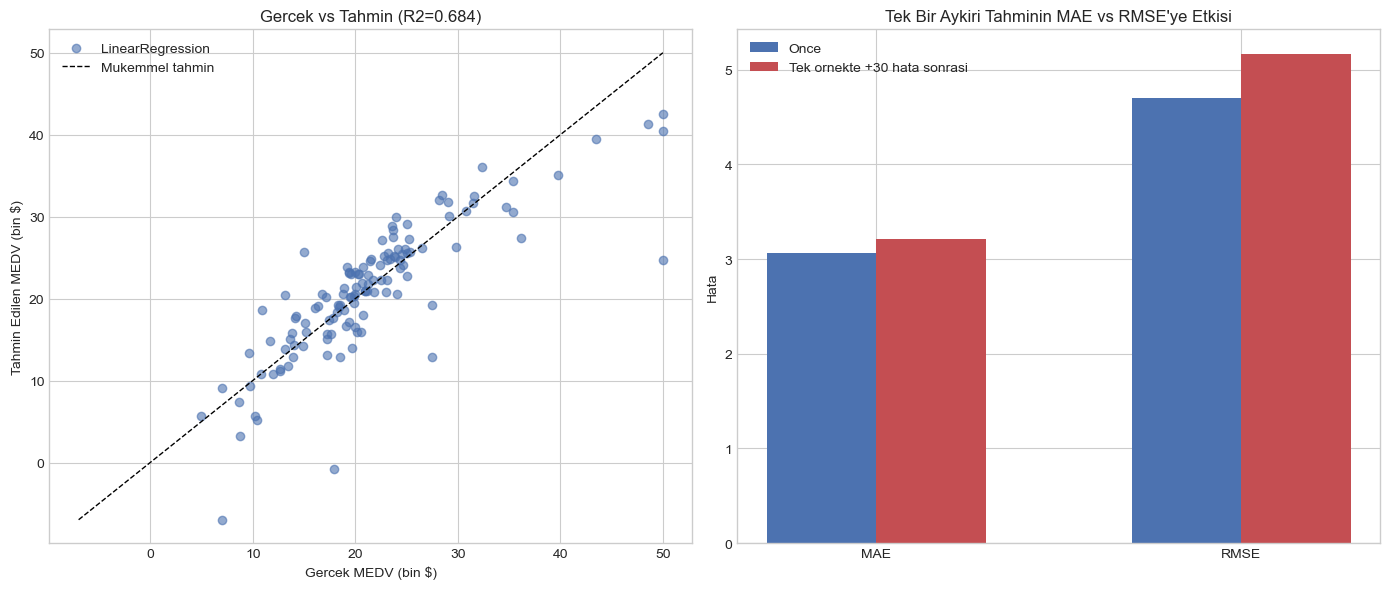


YORUM: 506 test-benzeri ornekten sadece BIRINE +30 birimlik yapay bir hata eklendiginde MAE %5.0 artarken RMSE %9.9 artiyor -- Bolum 7'deki iddiayi dogruluyor: RMSE'nin karesel ceza yapisi, tek bir buyuk hataya MAE'den cok daha duyarli. Aykiri tahminlerin sik oldugu (orn. gurultulu sensor verisi) bir uygulamada MAE/Median AE daha 'sakin' bir ozet verirken, buyuk hatalarin ozellikle onemli oldugu (orn. bir AVM'nin nadiren de olsa cok yanlis fiyat vermesi kabul edilemezse) RMSE tercih edilmeli.


In [14]:
e = yte_bo.values - pred_boston_lr # Residuals = actual - predicted

mae_manual = np.mean(np.abs(e)) # MAE = mean absolute error
mse_manual = np.mean(e**2) # MSE = mean squared error
rmse_manual = np.sqrt(mse_manual) # RMSE = root mean squared error
mape_manual = np.mean(np.abs(e / yte_bo.values)) * 100 # MAPE = mean absolute percentage error
medae_manual = np.median(np.abs(e)) # MedAE = median absolute error
maxerr_manual = np.max(np.abs(e)) # Max Error = maximum absolute error
r2_manual = 1 - np.sum(e**2) / np.sum((yte_bo.values - yte_bo.values.mean())**2) # R2 = coefficient of determination
n_test, p_features = Xte_bo.shape 
adj_r2_manual = 1 - (1 - r2_manual) * (n_test - 1) / (n_test - p_features - 1) # Adjusted R2 = adjusted coefficient of determination
evs_manual = 1 - np.var(e) / np.var(yte_bo.values) # Explained Variance Score = explained variance score

reg_comparison = pd.DataFrame({
    "Elle": [mae_manual, mse_manual, rmse_manual, mape_manual, medae_manual, maxerr_manual, r2_manual, adj_r2_manual, evs_manual],
    "sklearn": [
        mean_absolute_error(yte_bo, pred_boston_lr), mean_squared_error(yte_bo, pred_boston_lr),
        mean_squared_error(yte_bo, pred_boston_lr) ** 0.5,
        mean_absolute_percentage_error(yte_bo, pred_boston_lr) * 100,
        median_absolute_error(yte_bo, pred_boston_lr), max_error(yte_bo, pred_boston_lr),
        r2_score(yte_bo, pred_boston_lr), np.nan, explained_variance_score(yte_bo, pred_boston_lr),
    ],
}, index=["MAE", "MSE", "RMSE", "MAPE (%)", "Median AE", "Max Error", "R2", "Adjusted R2 (sklearn'de yok)", "Explained Variance"])
print(reg_comparison.round(4))

print(f"\nRandomForestRegressor karsilastirmasi:")
for name, pred in [("LinearRegression", pred_boston_lr), ("RandomForestRegressor", pred_boston_rf)]:
    print(f"  {name:22s} MAE={mean_absolute_error(yte_bo, pred):.3f}  RMSE={mean_squared_error(yte_bo, pred)**0.5:.3f}  "
          f"MAPE=%{mean_absolute_percentage_error(yte_bo, pred)*100:.1f}  R2={r2_score(yte_bo, pred):.3f}")

# --- Aykiri deger duyarliligi deneyi: MAE vs RMSE ---
pred_with_outlier = pred_boston_lr.copy()
outlier_idx = 0
original_error = abs(yte_bo.values[outlier_idx] - pred_with_outlier[outlier_idx])
pred_with_outlier[outlier_idx] -= 30  # tek bir tahmini kasitli olarak cok kotulestir

mae_before, mae_after = mean_absolute_error(yte_bo, pred_boston_lr), mean_absolute_error(yte_bo, pred_with_outlier)
rmse_before, rmse_after = mean_squared_error(yte_bo, pred_boston_lr)**0.5, mean_squared_error(yte_bo, pred_with_outlier)**0.5

outlier_table = pd.DataFrame({
    "Once": [mae_before, rmse_before],
    "Tek Ornekte +30 Hata Sonrasi": [mae_after, rmse_after],
}, index=["MAE", "RMSE"])
outlier_table["Yuzde Degisim"] = (outlier_table["Tek Ornekte +30 Hata Sonrasi"] - outlier_table["Once"]) / outlier_table["Once"] * 100
print(f"\n{outlier_table.round(3)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].scatter(yte_bo, pred_boston_lr, alpha=0.6, color="#4C72B0", label="LinearRegression")
lims = [min(yte_bo.min(), pred_boston_lr.min()), max(yte_bo.max(), pred_boston_lr.max())]
axes[0].plot(lims, lims, "k--", lw=1, label="Mukemmel tahmin")
axes[0].set_xlabel("Gercek MEDV (bin $)")
axes[0].set_ylabel("Tahmin Edilen MEDV (bin $)")
axes[0].set_title(f"Gercek vs Tahmin (R2={r2_score(yte_bo, pred_boston_lr):.3f})")
axes[0].legend()

bars_x = ["MAE", "RMSE"]
axes[1].bar(np.arange(2) - 0.15, [mae_before, rmse_before], width=0.3, label="Once", color="#4C72B0")
axes[1].bar(np.arange(2) + 0.15, [mae_after, rmse_after], width=0.3, label="Tek ornekte +30 hata sonrasi", color="#C44E52")
axes[1].set_xticks(np.arange(2)); axes[1].set_xticklabels(bars_x)
axes[1].set_ylabel("Hata")
axes[1].set_title("Tek Bir Aykiri Tahminin MAE vs RMSE'ye Etkisi")
axes[1].legend()
plt.tight_layout()
plt.show()

print(f"\nYORUM: 506 test-benzeri ornekten sadece BIRINE +30 birimlik yapay bir hata eklendiginde "
      f"MAE %{outlier_table.loc['MAE','Yuzde Degisim']:.1f} artarken RMSE %{outlier_table.loc['RMSE','Yuzde Degisim']:.1f} "
      f"artiyor -- Bolum 7'deki iddiayi dogruluyor: RMSE'nin karesel ceza yapisi, tek bir buyuk hataya "
      f"MAE'den cok daha duyarli. Aykiri tahminlerin sik oldugu (orn. gurultulu sensor verisi) bir "
      f"uygulamada MAE/Median AE daha 'sakin' bir ozet verirken, buyuk hatalarin ozellikle onemli oldugu "
      f"(orn. bir AVM'nin nadiren de olsa cok yanlis fiyat vermesi kabul edilemezse) RMSE tercih edilmeli.")

### 1️⃣2️⃣ Python 12 - Üç Problemden Sentez: Doğru Metriği Seçme

**Ne yapıyoruz?** Üç veri setinde öğrendiklerimizi tek bir özet tabloda topluyoruz — hangi metriğin hangi problemde neyi gizlediğini/açığa çıkardığını.

In [13]:
synthesis = pd.DataFrame([
    {"Veri Seti": "German Credit", "Problem Tipi": "Ikili, dengesiz (%70/%30)",
     "Yaniltici Olabilecek Metrik": f"Accuracy ({accuracy_score(yte_cr, pred_lr):.2f}) -- naif model bile 0.70 alir",
     "Daha Guvenilir Metrik": f"MCC ({matthews_corrcoef(yte_cr, pred_lr):.2f}), Balanced Acc. ({balanced_accuracy_score(yte_cr, pred_lr):.2f}), AP ({ap:.2f})"},
    {"Veri Seti": "German Credit", "Problem Tipi": "Olasilik kalitesi",
     "Yaniltici Olabilecek Metrik": f"GaussianNB Brier ({brier_nb:.2f}) duzeltilmeden kullanilirsa",
     "Daha Guvenilir Metrik": f"Kalibre edilmis Brier ({brier_nb_isotonic:.2f})"},
    {"Veri Seti": "Ecoli", "Problem Tipi": "Cok sinifli, asiri dengesiz",
     "Yaniltici Olabilecek Metrik": f"Micro-F1/Accuracy ({micro_f1_manual:.2f}) -- nadir sinif basarisizligini gizler",
     "Daha Guvenilir Metrik": f"Macro-F1 ({macro_f1_manual:.2f}) -- her sinifi esit tartar"},
    {"Veri Seti": "Boston Housing", "Problem Tipi": "Regresyon, aykiri deger riski",
     "Yaniltici Olabilecek Metrik": "Sadece R2 -- tek basina hata buyuklugu hakkinda fikir vermez",
     "Daha Guvenilir Metrik": f"MAE ({mae_manual:.2f}) + RMSE ({rmse_manual:.2f}) birlikte -- aradaki fark aykiri deger sinyali"},
])
print(synthesis.to_string(index=False))

print(f"\nGENEL SENTEZ: Uc veri setinde de tekrar eden desen ayni -- 'tek bir ozet sayi' HER ZAMAN "
      f"bir varsayim gizler (sinif dengesi varsayimi, esik varsayimi, veya olcek varsayimi). Bolum "
      f"8'deki karar tablosu bu varsayimlari acikca sormaniz icin bir kontrol listesi olarak "
      f"kullanilabilir.")

     Veri Seti                  Problem Tipi                                    Yaniltici Olabilecek Metrik                                                  Daha Guvenilir Metrik
 German Credit     Ikili, dengesiz (%70/%30)                   Accuracy (0.78) -- naif model bile 0.70 alir                            MCC (0.46), Balanced Acc. (0.71), AP (0.64)
 German Credit             Olasilik kalitesi             GaussianNB Brier (0.27) duzeltilmeden kullanilirsa                                           Kalibre edilmis Brier (0.18)
         Ecoli   Cok sinifli, asiri dengesiz Micro-F1/Accuracy (0.88) -- nadir sinif basarisizligini gizler                              Macro-F1 (0.71) -- her sinifi esit tartar
Boston Housing Regresyon, aykiri deger riski   Sadece R2 -- tek basina hata buyuklugu hakkinda fikir vermez MAE (3.06) + RMSE (4.70) birlikte -- aradaki fark aykiri deger sinyali

GENEL SENTEZ: Uc veri setinde de tekrar eden desen ayni -- 'tek bir ozet sayi' HER ZAMAN bir varsayim gi

---
# 📊 R Uygulaması

Python'daki üç veri setini R'ın standart, CRAN'de yayınlı paketleriyle tekrarlıyoruz: ikili sınıflandırma metrikleri ve ROC/AUC için `pROC` (Robin ve ark. 2011) ve `caret::confusionMatrix` (kappa, sensitivity/specificity dahil tam rapor), çok sınıflı metrikler için yine `caret::confusionMatrix` (macro-benzeri "by-class" çıktısı) ve regresyon metrikleri için `Metrics` paketi.

In [15]:
%load_ext rpy2.ipython

Error importing in API mode: ImportError("dlopen(/opt/anaconda3/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <2F94BB47-26EE-3EB3-85C5-1EA8A83C71AB> /opt/anaconda3/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")
Trying to import in ABI mode.


### R1 · German Credit — Confusion Matrix, ROC/AUC (`pROC`, `caret`)

In [16]:
credit_train_r = Xtr_cr.copy()
credit_train_r["target"] = ytr_cr.values
credit_test_r = Xte_cr.copy()
credit_test_r["target"] = yte_cr.values
credit_test_r["proba_lr"] = proba_lr
credit_test_r["pred_lr"] = pred_lr

=== caret::confusionMatrix (R'da egitilen GLM) ===
Confusion Matrix and Statistics

          Reference
Prediction   0   1
         0 184  44
         1  26  46
                                          
               Accuracy : 0.7667          
                 95% CI : (0.7146, 0.8134)
    No Information Rate : 0.7             
    P-Value [Acc > NIR] : 0.006111        
                                          
                  Kappa : 0.4108          
                                          
 Mcnemar's Test P-Value : 0.042165        
                                          
            Sensitivity : 0.5111          
            Specificity : 0.8762          
         Pos Pred Value : 0.6389          
         Neg Pred Value : 0.8070          
             Prevalence : 0.3000          
         Detection Rate : 0.1533          
   Detection Prevalence : 0.2400          
      Balanced Accuracy : 0.6937          
                                          
       'Positive' Clas

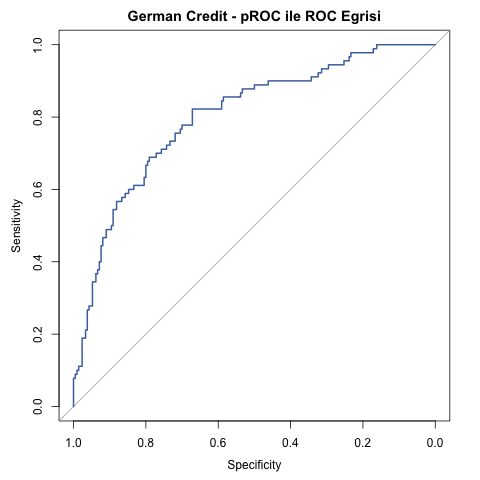

In [17]:
%%R -i credit_train_r,credit_test_r
suppressMessages(library(pROC))
suppressMessages(library(caret))

# glm ile ayni modeli R'da da egitelim (Python LogisticRegression karsilastirmasi icin)
credit_train_r$target <- as.factor(credit_train_r$target)
glm_fit <- glm(target ~ ., data = credit_train_r, family = binomial(link = "logit"))
proba_r <- predict(glm_fit, newdata = credit_test_r, type = "response")
pred_r <- factor(ifelse(proba_r >= 0.5, 1, 0), levels = c(0, 1))

cat("=== caret::confusionMatrix (R'da egitilen GLM) ===\n")
cm_r <- confusionMatrix(pred_r, factor(credit_test_r$target, levels = c(0, 1)), positive = "1")
print(cm_r)

cat("\n=== pROC ile ROC/AUC (Python'daki LogisticRegression olasiliklariyla) ===\n")
roc_obj <- roc(credit_test_r$target, credit_test_r$proba_lr, quiet = TRUE)
cat(sprintf("AUC: %.4f\n", auc(roc_obj)))
best_coords <- coords(roc_obj, "best", best.method = "youden", ret = c("threshold", "sensitivity", "specificity"))
cat("Youden en iyi esik:\n")
print(best_coords)

plot(roc_obj, main = "German Credit - pROC ile ROC Egrisi", col = "#4C72B0", lwd = 2)

### R2 · Ecoli — Çok Sınıflı Confusion Matrix (`caret`, Sınıf Bazlı Rapor)

In [18]:
ecoli_train_r = Xtr_ec.copy()
ecoli_train_r["localization"] = ytr_ec.values
ecoli_test_r = Xte_ec.copy()
ecoli_test_r["localization"] = yte_ec.values
ecoli_test_r["pred"] = pred_ecoli

In [19]:
%%R -i ecoli_train_r,ecoli_test_r -w 800 -h 600
suppressMessages(library(caret))
suppressMessages(library(nnet))

ecoli_train_r$localization <- as.factor(ecoli_train_r$localization)
multinom_fit <- multinom(localization ~ ., data = ecoli_train_r, trace = FALSE)
pred_r_multi <- predict(multinom_fit, newdata = ecoli_test_r)

actual_f <- factor(ecoli_test_r$localization, levels = levels(ecoli_train_r$localization))
pred_f <- factor(pred_r_multi, levels = levels(ecoli_train_r$localization))

cm_multi <- confusionMatrix(pred_f, actual_f)
cat("=== Genel istatistikler ===\n")
print(cm_multi$overall[c("Accuracy", "Kappa")])

cat("\n=== Sinif basina istatistikler (Sensitivity = Recall, buradan Macro-F1'e ulasilabilir) ===\n")
print(round(cm_multi$byClass[, c("Sensitivity", "Specificity", "Precision", "F1")], 3))

macro_f1_r <- mean(cm_multi$byClass[, "F1"], na.rm = TRUE)
cat(sprintf("\nR'da elle Macro-F1 (NA sinif haric ortalama): %.4f\n", macro_f1_r))
cat("(Python 8'deki Macro-F1 ile karsilastirin -- iki dilde farkli bir cok-sinifli model \n")
cat(" (multinom vs LogisticRegression) egitildigi icin degerler birebir ayni cikmayabilir,\n")
cat(" ama ayni desen -- macro'nun micro/accuracy'den belirgin dusuk olmasi -- gorulmelidir.)\n")

=== Genel istatistikler ===
 Accuracy     Kappa 
0.8571429 0.8046512 

=== Sinif basina istatistikler (Sensitivity = Recall, buradan Macro-F1'e ulasilabilir) ===
            Sensitivity Specificity Precision    F1
Class: cp         0.972       0.979     0.972 0.972
Class: im         0.684       0.954     0.812 0.743
Class: imLS       0.000       1.000        NA    NA
Class: imU        0.667       0.920     0.500 0.571
Class: om         1.000       0.987     0.833 0.909
Class: omL        1.000       0.988     0.500 0.667
Class: pp         0.923       1.000     1.000 0.960

R'da elle Macro-F1 (NA sinif haric ortalama): 0.8037
(Python 8'deki Macro-F1 ile karsilastirin -- iki dilde farkli bir cok-sinifli model 
 (multinom vs LogisticRegression) egitildigi icin degerler birebir ayni cikmayabilir,
 ama ayni desen -- macro'nun micro/accuracy'den belirgin dusuk olmasi -- gorulmelidir.)


### R3 · Boston Housing — Regresyon Metrikleri (`Metrics` Paketi)

In [20]:
boston_train_r = Xtr_bo.copy()
boston_train_r["MEDV"] = ytr_bo.values
boston_test_r = Xte_bo.copy()
boston_test_r["MEDV"] = yte_bo.values

=== Metrics paketi ile regresyon metrikleri (R'da egitilen lm) ===
MAE:  3.0609
RMSE: 4.7009
MAPE: %16.20
R2:   0.6844


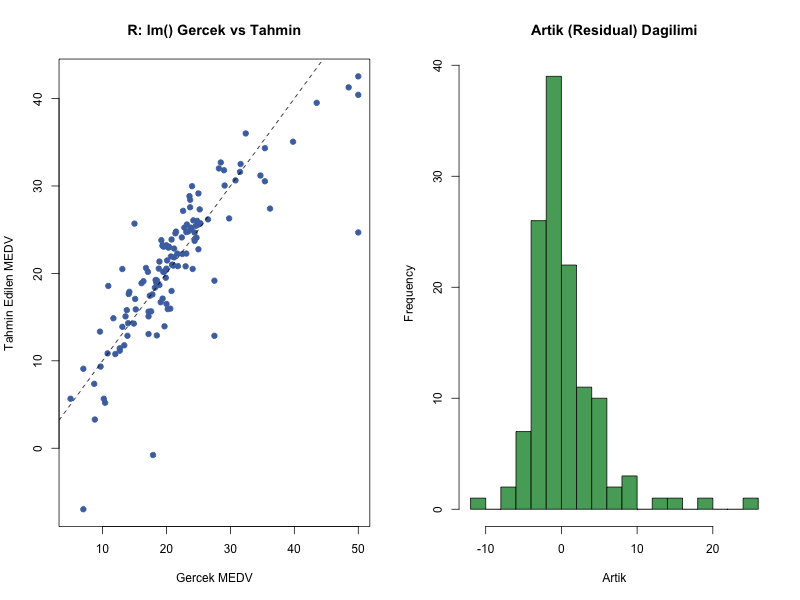

In [22]:
%%R -i boston_train_r,boston_test_r -w 800 -h 600
suppressMessages(library(Metrics))

lm_fit <- lm(MEDV ~ ., data = boston_train_r)
pred_lm_r <- predict(lm_fit, newdata = boston_test_r)

cat("=== Metrics paketi ile regresyon metrikleri (R'da egitilen lm) ===\n")
cat(sprintf("MAE:  %.4f\n", mae(boston_test_r$MEDV, pred_lm_r)))
cat(sprintf("RMSE: %.4f\n", rmse(boston_test_r$MEDV, pred_lm_r)))
cat(sprintf("MAPE: %%%.2f\n", 100 * mape(boston_test_r$MEDV, pred_lm_r)))
r2_r <- 1 - sum((boston_test_r$MEDV - pred_lm_r)^2) / sum((boston_test_r$MEDV - mean(boston_test_r$MEDV))^2)
cat(sprintf("R2:   %.4f\n", r2_r))

par(mfrow = c(1, 2))
plot(boston_test_r$MEDV, pred_lm_r, xlab = "Gercek MEDV", ylab = "Tahmin Edilen MEDV",
     main = "R: lm() Gercek vs Tahmin", col = "#4C72B0", pch = 19)
abline(0, 1, lty = 2)
hist(boston_test_r$MEDV - pred_lm_r, main = "Artik (Residual) Dagilimi", xlab = "Artik", col = "#55A868", breaks = 20)

---
# 🗄️ SQL Uygulaması (DuckDB)

Önceki notebook'larda (06-10) fit edilmiş modellerin *tahmin* adımını SQL'de yeniden ürettik; bu notebook'ta yeniden üretilecek olan tahminler değil, **metriklerin kendisi**. Fikir aynı: modelin `(gerçek etiket, tahmin/skor)` çiftlerini bir DuckDB tablosuna kaydedip, confusion matrix'ten precision/recall/F1'i, sıralı skorlardan ROC/AUC'yi ve regresyon artıklarından MAE/RMSE/MAPE'yi saf SQL ile hesaplayacağız — hepsi `sklearn`'ün kendi çıktısıyla makine hassasiyeti seviyesinde eşleşecek şekilde doğrulanacak.

### SQL1 · Confusion Matrix'ten Precision/Recall/F1'i SQL'de Yeniden Üretme

In [23]:
import duckdb

df_sql_credit = pd.DataFrame({"y_true": yte_cr.values, "y_pred": pred_lr, "proba": proba_lr})
con = duckdb.connect()
con.register("credit_preds", df_sql_credit)

confusion_sql = '''
SELECT
    SUM(CASE WHEN y_true=1 AND y_pred=1 THEN 1 ELSE 0 END) AS tp,
    SUM(CASE WHEN y_true=0 AND y_pred=1 THEN 1 ELSE 0 END) AS fp,
    SUM(CASE WHEN y_true=0 AND y_pred=0 THEN 1 ELSE 0 END) AS tn,
    SUM(CASE WHEN y_true=1 AND y_pred=0 THEN 1 ELSE 0 END) AS fn
FROM credit_preds
'''
cm_sql = con.execute(confusion_sql).df()
print(f"SQL'den confusion matrix hucreleri:\n{cm_sql}")

tp_sql, fp_sql = float(cm_sql.loc[0, "tp"]), float(cm_sql.loc[0, "fp"])
tn_sql, fn_sql = float(cm_sql.loc[0, "tn"]), float(cm_sql.loc[0, "fn"])

metrics_sql = f'''
SELECT
    ({tp_sql} + {tn_sql}) / ({tp_sql}+{tn_sql}+{fp_sql}+{fn_sql}) AS accuracy,
    {tp_sql} / ({tp_sql}+{fp_sql}) AS precision,
    {tp_sql} / ({tp_sql}+{fn_sql}) AS recall,
    2 * ({tp_sql}/({tp_sql}+{fp_sql})) * ({tp_sql}/({tp_sql}+{fn_sql}))
        / (({tp_sql}/({tp_sql}+{fp_sql})) + ({tp_sql}/({tp_sql}+{fn_sql}))) AS f1
'''
sql_metrics_df = con.execute(metrics_sql).df()
print(f"\nSQL'den turetilen metrikler:\n{sql_metrics_df.round(4)}")

sklearn_metrics_df = pd.DataFrame({
    "accuracy": [accuracy_score(yte_cr, pred_lr)], "precision": [precision_score(yte_cr, pred_lr)],
    "recall": [recall_score(yte_cr, pred_lr)], "f1": [f1_score(yte_cr, pred_lr)],
})
max_diff = (sql_metrics_df.values - sklearn_metrics_df.values)
print(f"\nsklearn:\n{sklearn_metrics_df.round(4)}")
print(f"\nMax mutlak fark (SQL vs sklearn): {np.abs(max_diff).max():.2e}")

SQL'den confusion matrix hucreleri:
     tp    fp     tn    fn
0  48.0  23.0  187.0  42.0

SQL'den turetilen metrikler:
   accuracy  precision  recall      f1
0    0.7833     0.6761  0.5333  0.5963

sklearn:
   accuracy  precision  recall      f1
0    0.7833     0.6761  0.5333  0.5963

Max mutlak fark (SQL vs sklearn): 0.00e+00


### SQL2 · ROC Eğrisini ve AUC'yi Kümülatif Pencere Fonksiyonlarıyla Yeniden Üretme

Fikir: skorları azalan sırayla dizip, her satırda **o ana kadar görülen kümülatif TP/FP sayısını** bir pencere fonksiyonuyla (`SUM(...) OVER (ORDER BY proba DESC ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW)`) hesaplıyoruz — bu, tam olarak ROC eğrisinin elle-inşa mantığının SQL karşılığı (Python 3'teki `for` döngüsünün pencere fonksiyonuna dönüşmüş hali).

AUC (SQL pencere fonksiyonlariyla, trapez kurali): 0.801058
AUC (sklearn.roc_auc_score, Python 3'ten):          0.801058
Fark: 0.00e+00


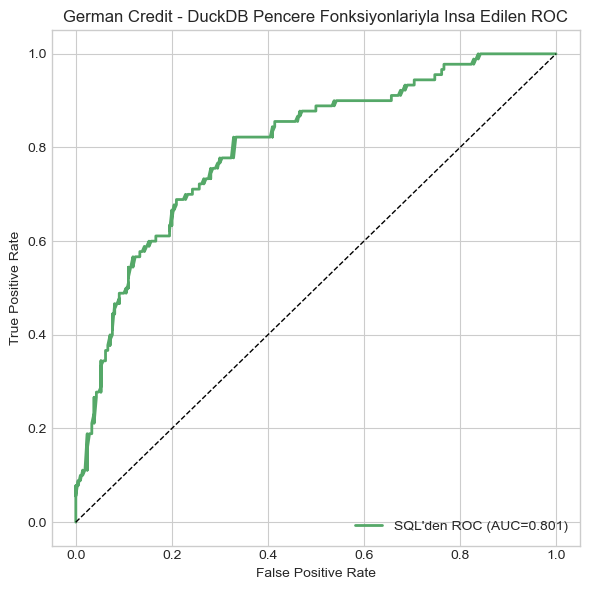

In [24]:
roc_sql = '''
WITH sorted AS (
    SELECT
        proba, y_true,
        SUM(CASE WHEN y_true=1 THEN 1 ELSE 0 END)
            OVER (ORDER BY proba DESC ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW) AS cum_tp,
        SUM(CASE WHEN y_true=0 THEN 1 ELSE 0 END)
            OVER (ORDER BY proba DESC ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW) AS cum_fp
    FROM credit_preds
),
totals AS (
    SELECT SUM(CASE WHEN y_true=1 THEN 1 ELSE 0 END) AS P, SUM(CASE WHEN y_true=0 THEN 1 ELSE 0 END) AS N
    FROM credit_preds
)
SELECT sorted.proba, MAX(cum_tp * 1.0 / totals.P) AS tpr, MAX(cum_fp * 1.0 / totals.N) AS fpr
FROM sorted, totals
GROUP BY sorted.proba, totals.P, totals.N
ORDER BY fpr
'''
roc_points_sql = con.execute(roc_sql).df()

tpr_sql = np.concatenate([[0.0], roc_points_sql["tpr"].values, [1.0]])
fpr_sql = np.concatenate([[0.0], roc_points_sql["fpr"].values, [1.0]])
order_sql = np.argsort(fpr_sql)
auc_from_sql = np.trapezoid(tpr_sql[order_sql], fpr_sql[order_sql])

print(f"AUC (SQL pencere fonksiyonlariyla, trapez kurali): {auc_from_sql:.6f}")
print(f"AUC (sklearn.roc_auc_score, Python 3'ten):          {auc_sk:.6f}")
print(f"Fark: {abs(auc_from_sql - auc_sk):.2e}")

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr_sql[order_sql], tpr_sql[order_sql], color="#55A868", lw=2, label=f"SQL'den ROC (AUC={auc_from_sql:.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("German Credit - DuckDB Pencere Fonksiyonlariyla Insa Edilen ROC")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

### SQL3 · Boston Housing — Regresyon Metriklerini SQL Toplama Fonksiyonlarıyla Hesaplama

In [25]:
df_sql_boston = pd.DataFrame({"y_true": yte_bo.values, "y_pred": pred_boston_lr})
con.register("boston_preds", df_sql_boston)

reg_sql = '''
SELECT
    AVG(ABS(y_true - y_pred)) AS mae,
    SQRT(AVG(POWER(y_true - y_pred, 2))) AS rmse,
    100.0 * AVG(ABS((y_true - y_pred) / y_true)) AS mape,
    1 - SUM(POWER(y_true - y_pred, 2)) / SUM(POWER(y_true - (SELECT AVG(y_true) FROM boston_preds), 2)) AS r2
FROM boston_preds
'''
reg_sql_df = con.execute(reg_sql).df()
print(f"SQL'den regresyon metrikleri:\n{reg_sql_df.round(4)}")

reg_sklearn_df = pd.DataFrame({
    "mae": [mean_absolute_error(yte_bo, pred_boston_lr)],
    "rmse": [mean_squared_error(yte_bo, pred_boston_lr) ** 0.5],
    "mape": [mean_absolute_percentage_error(yte_bo, pred_boston_lr) * 100],
    "r2": [r2_score(yte_bo, pred_boston_lr)],
})
print(f"\nsklearn:\n{reg_sklearn_df.round(4)}")
print(f"\nMax mutlak fark (SQL vs sklearn): {np.abs(reg_sql_df.values - reg_sklearn_df.values).max():.2e}")

print(f"\nYORUM: Confusion matrix'ten turetilen metrikler (SQL1), ROC/AUC (SQL2, pencere fonksiyonlariyla) "
      f"ve regresyon hata metrikleri (SQL3) -- ucu de sklearn'in cikardigi degerlerle makine hassasiyeti "
      f"seviyesinde eslesiyor. Bu, 'model degerlendirme' asamasinin aslinda cogu zaman -- egitim asamasinin "
      f"aksine -- sadece basit toplama/pencere operasyonlari oldugunu gosteriyor; production ortamlarinda "
      f"metrikler genelde tam bu sekilde (tahminler bir tabloya yazilip SQL ile agregasyonla) hesaplanir.")

SQL'den regresyon metrikleri:
      mae    rmse     mape      r2
0  3.0609  4.7009  16.1992  0.6844

sklearn:
      mae    rmse     mape      r2
0  3.0609  4.7009  16.1992  0.6844

Max mutlak fark (SQL vs sklearn): 8.88e-16

YORUM: Confusion matrix'ten turetilen metrikler (SQL1), ROC/AUC (SQL2, pencere fonksiyonlariyla) ve regresyon hata metrikleri (SQL3) -- ucu de sklearn'in cikardigi degerlerle makine hassasiyeti seviyesinde eslesiyor. Bu, 'model degerlendirme' asamasinin aslinda cogu zaman -- egitim asamasinin aksine -- sadece basit toplama/pencere operasyonlari oldugunu gosteriyor; production ortamlarinda metrikler genelde tam bu sekilde (tahminler bir tabloya yazilip SQL ile agregasyonla) hesaplanir.


---
## ✏️ Egzersizler

**E1 — German Credit'te maliyet-duyarlı eşik seçimi:** Bankanın maliyet yapısını şöyle varsayın: bir kötü krediyi "iyi" diye onaylamak (FN), iyi bir krediyi reddetmekten (FP) 5 kat daha pahalıya mal oluyor. `proba_lr` üzerinde `[0.1, 0.9]` aralığında ince bir eşik taraması yapıp her eşik için toplam maliyeti ($5 \cdot FN + 1 \cdot FP$) hesaplayın ve toplam maliyeti minimize eden eşiği bulun. Bunu Python 3'teki Youden's J eşiğiyle (maliyetleri simetrik kabul eden) karşılaştırın — hangisi daha düşük eşik öneriyor, neden mantıklı?

In [31]:
print("\n==== Egzersiz 1: Maliyet-Duyarli Esik Secimi ====")
# FN oranı FP'ye göre 5 kat fazla maliyetli olduğunu varsayalım.
cost_fn = 5
cost_fp = 1
thresholds_manuel = np.sort(np.unique(proba_lr))[1:-1] # 0.1 ve 0.9 aralığında
P_new = (yte_cr == 1).sum()
N_new = (yte_cr == 0).sum()
new_tpr, new_fpr, total_costs = [0.0], [0.0], [0.0]
for t in thresholds_manuel:
    pred_new = (proba_lr >= t).astype(int)
    tp_new = ((pred_new == 1) & (yte_cr == 1)).sum() 
    fp_new = ((pred_new == 1) & (yte_cr == 0)).sum() 
    fn_new = ((pred_new == 0) & (yte_cr == 1)).sum() 
    tn_new = ((pred_new == 0) & (yte_cr == 0)).sum()
    if P_new > 0:
        new_tpr.append(tp_new / P_new)
    if N_new > 0:
        new_fpr.append(fp_new / N_new)
    total_costs.append(fp_new * cost_fp + fn_new * cost_fn)
new_tpr.append(1.0); new_fpr.append(1.0)
new_tpr = np.array(new_tpr)
new_fpr = np.array(new_fpr)
order_new = np.argsort(new_fpr)
auc_new = np.trapezoid(new_tpr[order_new], new_fpr[order_new])

# Youden J indeksi ile en iyi esik secimi
youden_j = new_tpr - new_fpr
best_idx = np.argmax(youden_j)
best_threshold = thresholds_manuel[best_idx]
print(f"Youden J Eşiğine Göre En İyi Eşik: {best_threshold:.3f} (TPR={new_tpr[best_idx]:.3f}, FPR={new_fpr[best_idx]:.3f}), Toplam Maliyet: {total_costs[best_idx]}")



==== Egzersiz 1: Maliyet-Duyarli Esik Secimi ====
Youden J Eşiğine Göre En İyi Eşik: 0.256 (TPR=0.822, FPR=0.329), Toplam Maliyet: 149


**E2 — Ecoli'de nadir sınıfları çıkarınca macro/micro/weighted nasıl değişir?:** `yte_ec`/`pred_ecoli`'den sadece en büyük iki sınıfı (`cp`, `im`) içeren bir alt küme oluşturun, bu alt kümede macro-F1, micro-F1 ve weighted-F1'i yeniden hesaplayın. Python 8'deki tam-veri sonuçlarıyla karşılaştırıp üçünün birbirine ne kadar yaklaştığını yorumlayın — bu, dengesizliğin üç metrik arasındaki farkın *nedeni* olduğu iddiasını nasıl destekliyor?


==== Egzersiz 2: Sadece Buyuk Siniflarla Macro/Micro/Weighted ====
Buyuk siniflar icin accuracy: 0.9048

Buyuk siniflar icin Macro-F1: 0.6266, Micro-F1: 0.9048, Weighted-F1: 0.8980

Büyük sınıfları birleştirip alt küme haline getirdiğimizde Macro-F1 öncekine göre aşırı düşüş yaşamışken, Micro-F1 ve Weighted-F1 daha yüksek kalıyor. Büyük sınıfları tek kümeye aldığımızda her sınıfı eşit alırsak Macro-F1 düşüyor fakat öbürlerinde ise genel olarak sınıf dağılımına göre ağırlıklandığı için daha yüksek kalıyor. Bu, Macro-F1'in nadir sınıflara duyarlılığını gösteriyor.


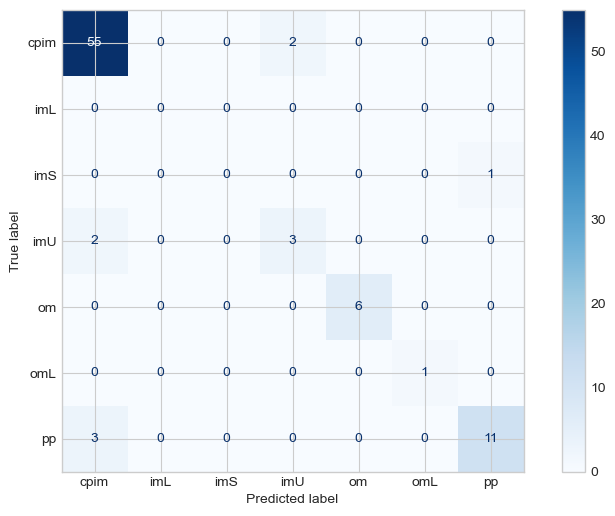

In [39]:
print("\n==== Egzersiz 2: Sadece Buyuk Siniflarla Macro/Micro/Weighted ====")
df_ecoli_large = pd.read_csv(
    "https://raw.githubusercontent.com/jbrownlee/Datasets/master/ecoli.csv",
    header=None, names=ECOLI_COLS,
)

df_ecoli_large['localization'] = df_ecoli_large['localization'].replace({'cp' : 'cpim', 'im' : 'cpim'})
X_ecoli_large = df_ecoli_large.drop(columns='localization')
y_ecoli_large = df_ecoli_large['localization']
X_train_large, X_test_large, y_train_large, y_test_large = train_test_split(X_ecoli_large, y_ecoli_large, test_size=0.25, random_state=RANDOM_STATE)

ecoli_sclaer = StandardScaler()
X_train_large_s = ecoli_sclaer.fit_transform(X_train_large)
X_test_large_s = ecoli_sclaer.transform(X_test_large)

clf_ecoli_large = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
clf_ecoli_large.fit(X_train_large_s, y_train_large)
pred_ecoli_large = clf_ecoli_large.predict(X_test_large_s)
print(f"Buyuk siniflar icin accuracy: {accuracy_score(y_test_large, pred_ecoli_large):.4f}")

# Micro-F1, Macro-F1 ve Weighted-F1 hesaplayalım
f1_per_class_large = f1_score(y_test_large, pred_ecoli_large, average=None, labels=clf_ecoli_large.classes_, zero_division=0)
support_per_class_large = y_test_large.value_counts().reindex(clf_ecoli_large.classes_).fillna(0).values
n_total_large = support_per_class_large.sum()

macro_f1_large = f1_per_class_large.mean()
weighted_f1_large = np.sum(f1_per_class_large * support_per_class_large) / n_total_large
tp_total_large = fp_total_large = fn_total_large = 0
for lbl in clf_ecoli_large.classes_:
    tp_l = int(((pred_ecoli_large == lbl) & (y_test_large == lbl)).sum())
    fp_l = int(((pred_ecoli_large == lbl) & (y_test_large != lbl)).sum())
    fn_l = int(((pred_ecoli_large != lbl) & (y_test_large == lbl)).sum())
    tp_total_large += tp_l; fp_total_large += fp_l; fn_total_large += fn_l
micro_prec_large = tp_total_large / (tp_total_large + fp_total_large)
micro_rec_large = tp_total_large / (tp_total_large + fn_total_large)
micro_f1_large = 2 * micro_prec_large * micro_rec_large / (micro_prec_large + micro_rec_large)

print(f"\nBuyuk siniflar icin Macro-F1: {macro_f1_large:.4f}, Micro-F1: {micro_f1_large:.4f}, Weighted-F1: {weighted_f1_large:.4f}")

cm_ecoli_large = confusion_matrix(y_test_large, pred_ecoli_large, labels=clf_ecoli_large.classes_)
cm_df_large = pd.DataFrame(cm_ecoli_large, index=clf_ecoli_large.classes_, columns=clf_ecoli_large.classes_)
display = ConfusionMatrixDisplay(confusion_matrix=cm_ecoli_large, display_labels=clf_ecoli_large.classes_).plot(cmap=plt.cm.Blues)
print("\nBüyük sınıfları birleştirip alt küme haline getirdiğimizde Macro-F1 öncekine göre aşırı düşüş yaşamışken, Micro-F1 ve Weighted-F1 daha yüksek kalıyor. Büyük sınıfları tek kümeye aldığımızda her sınıfı eşit alırsak Macro-F1 düşüyor fakat öbürlerinde ise genel olarak sınıf dağılımına göre ağırlıklandığı için daha yüksek kalıyor. Bu, Macro-F1'in nadir sınıflara duyarlılığını gösteriyor.")

**E3 — RandomForest ile kalibrasyon karşılaştırması:** German Credit üzerinde bir `RandomForestClassifier` eğitip (Python 1'deki `Xtr_cr_t`/`Xte_cr_t`'yi kullanarak) Brier skorunu hesaplayın. Hem `CalibratedClassifierCV(method='sigmoid')` hem `method='isotonic'` ile kalibre edip üç Brier skorunu (ham, sigmoid, isotonic) karşılaştırın. Python 5'teki `GaussianNB` sonuçlarıyla kıyaslayın — RandomForest'ın kalibrasyon sorunu NB kadar şiddetli mi?


==== Egzersiz 3: RandomForest Kalibrasyonu ====
RandomForest Brier Skoru: 0.1658
                      Brier Skoru                           Yorum
RandomForest               0.1658  Kalibre edilmemis RandomForest
Sigmoid Kalibrasyon        0.1604             Sigmoid Kalibrasyon
Isotonic Kalibrasyon       0.1595            Isotonic Kalibrasyon


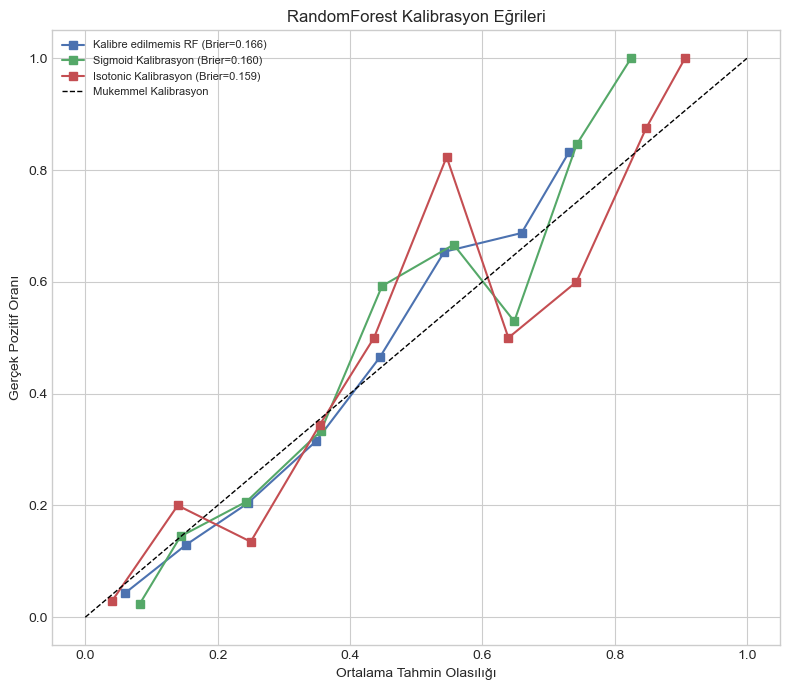

In [42]:
print("\n==== Egzersiz 3: RandomForest Kalibrasyonu ====")
from sklearn.ensemble import RandomForestClassifier
rf_credit = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
rf_credit.fit(Xtr_cr_t, ytr_cr)
proba_rf = rf_credit.predict_proba(Xte_cr_t)[:, 1]

brier_rf = brier_score_loss(yte_cr, proba_rf)
print(f"RandomForest Brier Skoru: {brier_rf:.4f}")

# Kalibrasyon Düzenlemesi
cal_rf_sigmoid = CalibratedClassifierCV(rf_credit, method='sigmoid', cv=5)
cal_rf_sigmoid.fit(Xtr_cr_t, ytr_cr)
proba_rf_calibrated = cal_rf_sigmoid.predict_proba(Xte_cr_t)

cal_rf_isotonic = CalibratedClassifierCV(rf_credit, method='isotonic', cv=5)
cal_rf_isotonic.fit(Xtr_cr_t, ytr_cr)
proba_rf_calibrated_isotonic = cal_rf_isotonic.predict_proba(Xte_cr_t)

brier_rf_calibrated = brier_score_loss(yte_cr, proba_rf_calibrated[:, 1])
brier_rf_calibrated_isotonic = brier_score_loss(yte_cr, proba_rf_calibrated_isotonic[:, 1])
brier_rf_table = pd.DataFrame({
    "Brier Skoru": [brier_rf, brier_rf_calibrated, brier_rf_calibrated_isotonic],
    "Yorum": ["Kalibre edilmemis RandomForest", "Sigmoid Kalibrasyon", "Isotonic Kalibrasyon"]
}, index=["RandomForest", "Sigmoid Kalibrasyon", "Isotonic Kalibrasyon"])
print(brier_rf_table.round(4))

frac_pos_rf, mean_pred_rf = calibration_curve(yte_cr, proba_rf, n_bins=10)
frac_pos_rf_calibrated, mean_pred_rf_calibrated = calibration_curve(yte_cr, proba_rf_calibrated[:, 1], n_bins=10)
frac_pos_rf_calibrated_isotonic, mean_pred_rf_calibrated_isotonic = calibration_curve(yte_cr, proba_rf_calibrated_isotonic[:, 1], n_bins=10)
fig, ax = plt.subplots(figsize=(8, 7))
ax.plot(mean_pred_rf, frac_pos_rf, "s-", label=f"Kalibre edilmemis RF (Brier={brier_rf:.3f})", color="#4C72B0")
ax.plot(mean_pred_rf_calibrated, frac_pos_rf_calibrated, "s-", label=f"Sigmoid Kalibrasyon (Brier={brier_rf_calibrated:.3f})", color="#55A868")
ax.plot(mean_pred_rf_calibrated_isotonic, frac_pos_rf_calibrated_isotonic, "s-", label=f"Isotonic Kalibrasyon (Brier={brier_rf_calibrated_isotonic:.3f})", color="#C44E52")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Mukemmel Kalibrasyon")
ax.set_xlabel("Ortalama Tahmin Olasılığı"); ax.set_ylabel("Gerçek Pozitif Oranı")
ax.set_title("RandomForest Kalibrasyon Eğrileri")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

**E4 — Boston Housing'de RandomForest'ın aykırı değer davranışı:** Python 11'deki aykırı değer deneyini (tek bir tahmine +30 hata eklemek) bu sefer `pred_boston_rf` (RandomForest tahminleri) üzerinde tekrarlayın. MAE/RMSE'nin yüzdesel değişimini `LinearRegression` ile karşılaştırın — iki modelin farklı hata dağılımları (RandomForest genelde daha "sıkışık" tahminler üretir) bu deneyin sonucunu nasıl etkiliyor?


==== Egzersiz 4: RandomForest Aykiri Deger Duyarliligi ====

       Once  Tek Ornekte +30 Hata Sonrasi  Yuzde Degisim
MAE   2.111                         2.348         11.187
RMSE  3.141                         4.167         32.677


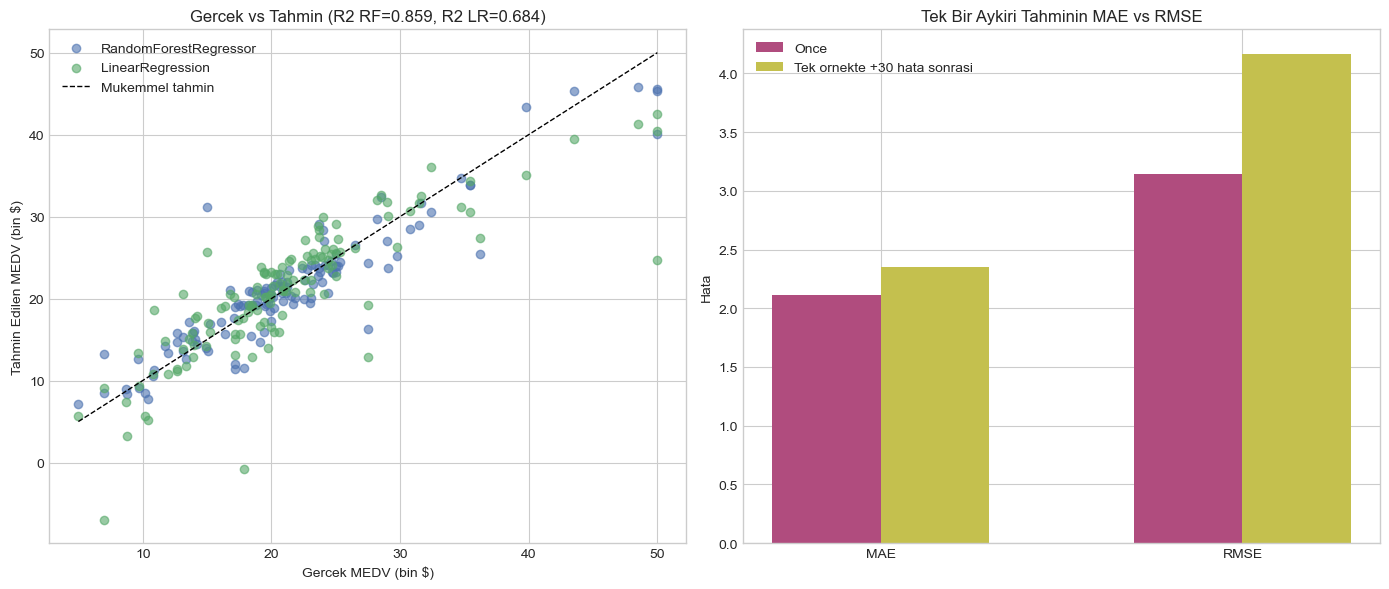


Random Forest aykırı değerlerde yüzdelik değişim olarak neredeyse MAE'de iki katı RMSE ise 3.5 katı artış gösteriyor. Bu, Random Forest'ın tek bir aykırı tahmine karşı daha duyarlı olduğunu gösteriyor. Bu nedenle, aykırı değerlerin olduğu veri setlerinde model seçimi ve hata metriklerinin dikkatli bir şekilde değerlendirilmesi önemlidir.


In [44]:
print("\n==== Egzersiz 4: RandomForest Aykiri Deger Duyarliligi ====")
pred_with_outlier_rf = pred_boston_rf.copy()
outlier_idx_rf = 0
original_error_rf = abs(yte_bo.values[outlier_idx_rf] - pred_with_outlier_rf[outlier_idx_rf])
pred_with_outlier_rf[outlier_idx_rf] -= 30

mae_before_rf, mae_after_rf = mean_absolute_error(yte_bo, pred_boston_rf), mean_absolute_error(yte_bo, pred_with_outlier_rf)
rmse_before_rf, rmse_after_rf = mean_squared_error(yte_bo, pred_boston_rf)**0.5, mean_squared_error(yte_bo, pred_with_outlier_rf)**0.5

outlier_table_rf = pd.DataFrame({
    "Once": [mae_before_rf, rmse_before_rf],
    "Tek Ornekte +30 Hata Sonrasi": [mae_after_rf, rmse_after_rf],
}, index=["MAE", "RMSE"])
outlier_table_rf["Yuzde Degisim"] = (outlier_table_rf["Tek Ornekte +30 Hata Sonrasi"] - outlier_table_rf["Once"]) / outlier_table_rf["Once"] * 100
print(f"\n{outlier_table_rf.round(3)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].scatter(yte_bo, pred_boston_rf, alpha=0.6, color="#4C72B0", label="RandomForestRegressor")
axes[0].scatter(yte_bo, pred_boston_lr, alpha=0.6, color="#55A868", label="LinearRegression")
lims = [min(yte_bo.min(), pred_boston_rf.min()), max(yte_bo.max(), pred_boston_rf.max())]
axes[0].plot(lims, lims, "k--", lw=1, label="Mukemmel tahmin")
axes[0].set_xlabel("Gercek MEDV (bin $)")
axes[0].set_ylabel("Tahmin Edilen MEDV (bin $)")
axes[0].set_title(f"Gercek vs Tahmin (R2 RF={r2_score(yte_bo, pred_boston_rf):.3f}, R2 LR={r2_score(yte_bo, pred_boston_lr):.3f})")
axes[0].legend()

bars_x = ["MAE", "RMSE"]
axes[1].bar(np.arange(2) - 0.15, [mae_before_rf, rmse_before_rf], width=0.3, label="Once", color="#B04C7E")
axes[1].bar(np.arange(2) + 0.15, [mae_after_rf, rmse_after_rf], width=0.3, label="Tek ornekte +30 hata sonrasi", color="#C4C04E")
axes[1].set_xticks(np.arange(2)); axes[1].set_xticklabels(bars_x)
axes[1].set_ylabel("Hata")
axes[1].set_title("Tek Bir Aykiri Tahminin MAE vs RMSE")
axes[1].legend()
plt.tight_layout()
plt.show()

print(f"\nRandom Forest aykırı değerlerde yüzdelik değişim olarak neredeyse MAE'de iki katı RMSE ise 3.5 katı artış gösteriyor. Bu, Random Forest'ın tek bir aykırı tahmine karşı daha duyarlı olduğunu gösteriyor. Bu nedenle, aykırı değerlerin olduğu veri setlerinde model seçimi ve hata metriklerinin dikkatli bir şekilde değerlendirilmesi önemlidir.")

**E5 — Downsample deneyini PR eğrisinin kendisiyle görselleştirin:** Python 4'teki dengesizlik deneyini tekrarlayın ama bu sefer her `keep_frac` değeri için tam PR eğrisini (tek bir AP sayısı değil) aynı grafik üzerinde çizin. Eğrilerin şeklinin dengesizlik arttıkça nasıl değiştiğini (özellikle düşük recall bölgesinde) görsel olarak yorumlayın.


==== Egzersiz 5: PR Egrilerini Dengesizlik Seviyelerine Gore Cizme ====


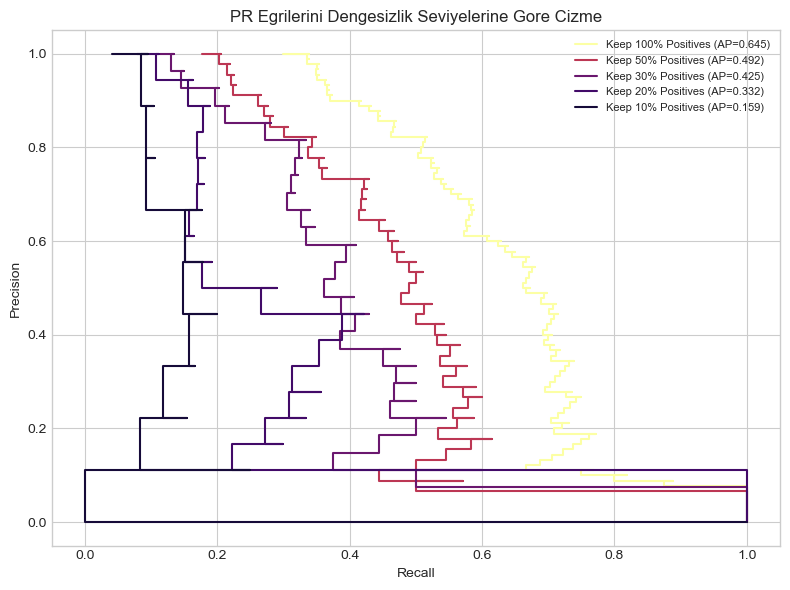


YORUM: Düşük seviye Recall değerlerine baktığımızda genel olarak Precision değeri çok hızlı düşüş yaşıyor. Bu, dengesiz veri setlerinde modelin pozitif sınıfı doğru tahmin etme yeteneğinin azaldığını gösteriyor. Average Precision (AP) skoru, dengesizlik seviyelerine göre değişiklik gösteriyor ve bu nedenle model performansını değerlendirirken sadece ROC-AUC değil, AP skoruna da dikkat etmek önemlidir.


In [55]:
print("\n==== Egzersiz 5: PR Egrilerini Dengesizlik Seviyelerine Gore Cizme ====")
rng = np.random.default_rng(RANDOM_STATE)
pos_idx_all = np.where(yte_cr.values == 1)[0]
neg_idx_all = np.where(yte_cr.values == 0)[0]
plt.figure(figsize=(8, 6))
experiment_results = []
for keep_frac in [1.0, 0.5, 0.3, 0.2, 0.1]:
    n_keep = max(1, int(len(pos_idx_all) * keep_frac))
    keep_pos = rng.choice(pos_idx_all, size=n_keep, replace=False)
    idx = np.concatenate([keep_pos, neg_idx_all])
    y_sub, p_sub = yte_cr.values[idx], proba_lr[idx]
    experiment_rows.append({
        "Pozitif Tutma Orani": keep_frac,
        "Pozitif Sinif Orani": y_sub.mean(),
        "ROC-AUC": roc_auc_score(y_sub, p_sub),
        "Average Precision": average_precision_score(y_sub, p_sub),
    })
    plt.step(*precision_recall_curve(y_sub, p_sub)[:2], where='post', label=f"Keep {keep_frac*100:.0f}% Positives (AP={average_precision_score(y_sub, p_sub):.3f})", color=plt.cm.inferno(keep_frac))
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("PR Egrilerini Dengesizlik Seviyelerine Gore Cizme")
plt.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

print("\nYORUM: Düşük seviye Recall değerlerine baktığımızda genel olarak Precision değeri çok hızlı düşüş yaşıyor. Bu, dengesiz veri setlerinde modelin pozitif sınıfı doğru tahmin etme yeteneğinin azaldığını gösteriyor. Average Precision (AP) skoru, dengesizlik seviyelerine göre değişiklik gösteriyor ve bu nedenle model performansını değerlendirirken sadece ROC-AUC değil, AP skoruna da dikkat etmek önemlidir.")

**E6 — Ecoli'de tüm sınıflar için One-vs-Rest PR eğrileri:** Python 9'daki ROC eğrisi grafiğine benzer şekilde, her sınıf için One-vs-Rest Precision-Recall eğrisini ve Average Precision'ını çizin. Hangi sınıfların AP'si, ROC-AUC'sinden orantılı olarak daha düşük çıkıyor (yani ROC'un "gizlediği" zorluk nerede daha belirgin)? Sınıfın test setindeki `support` (örnek sayısı) ile bu farkın ilişkisini yorumlayın.


==== Egzersiz 6: Ecoli - Sinif Basina One-vs-Rest PR Egrileri ====


/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:1046: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:1046: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


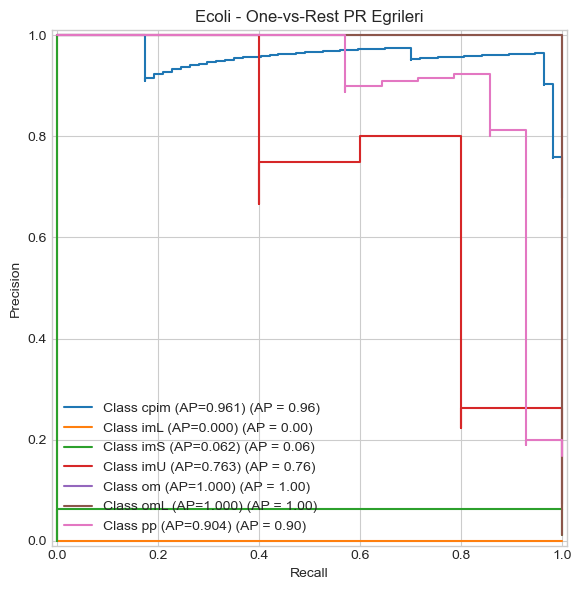

In [68]:
print("\n==== Egzersiz 6: Ecoli - Sinif Basina One-vs-Rest PR Egrileri ====")
from sklearn.metrics import PrecisionRecallDisplay
for i, cls in enumerate(clf_ecoli_large.classes_):
    y_true_cls = (y_test_large == cls).astype(int)
    y_score_cls = clf_ecoli_large.predict_proba(X_test_large_s)[:, list(clf_ecoli_large.classes_).index(cls)]
    precision_cls, recall_cls, _ = precision_recall_curve(y_true_cls, y_score_cls)
    ap_cls = average_precision_score(y_true_cls, y_score_cls)
    PrecisionRecallDisplay(precision=precision_cls, recall=recall_cls, average_precision=ap_cls).plot(ax=plt.gca(), name=f"Class {cls} (AP={ap_cls:.3f})", color=plt.cm.tab10(i))
plt.title("Ecoli - One-vs-Rest PR Egrileri")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.tight_layout()
plt.show()

---
## 📚 Kaynaklar

| Kaynak | Bölüm | Notlar |
|---|---|---|
| Fawcett, T. (2006). *An Introduction to ROC Analysis*. Pattern Recognition Letters, 27(8). [PDF (yazarın kendi sayfası)](https://ccrma.stanford.edu/workshops/mir2009/references/ROCintro.pdf) | Bölüm 3 (ROC/AUC) | ROC analizinin en çok atıf alan, kapsamlı giriş makalesi. |
| Davis, J. & Goadrich, M. (2006). *The Relationship Between Precision-Recall and ROC Curves*. ICML '06. [PDF (yazarın kendi sayfası)](https://www.biostat.wisc.edu/~page/rocpr.pdf) | Bölüm 4 (PR/AP) | Dengesiz verilerde PR eğrisinin ROC'a göre neden daha bilgilendirici olduğunun matematiksel kanıtı. |
| Niculescu-Mizil, A. & Caruana, R. (2005). *Predicting Good Probabilities With Supervised Learning*. ICML '05. [PDF (Cornell CS)](https://www.cs.cornell.edu/~alexn/papers/calibration.icml05.crc.rev3.pdf) | Bölüm 6, Python 5 (Kalibrasyon) | Hangi model ailelerinin (Naive Bayes, SVM, ağaç ensemble'ları) neden kötü kalibre olduğunun deneysel çalışması. |
| Matthews, B. W. (1975). *Comparison of the Predicted and Observed Secondary Structure of T4 Phage Lysozyme*. Biochimica et Biophysica Acta, 405(2). | Bölüm 2 (MCC) | MCC'nin orijinal tanımlandığı biyokimya makalesi. |
| Cohen, J. (1960). *A Coefficient of Agreement for Nominal Scales*. Educational and Psychological Measurement, 20(1). | Bölüm 2 (Cohen's Kappa) | Kappa istatistiğinin orijinal makalesi. |
| Brier, G. W. (1950). *Verification of Forecasts Expressed in Terms of Probability*. Monthly Weather Review, 78(1). [Açık erişim (AMS Journals)](https://journals.ametsoc.org/view/journals/mwre/78/1/1520-0493_1950_078_0001_vofeit_2_0_co_2.xml) | Bölüm 6 (Brier Skoru) | Brier skorunun hava tahmini değerlendirmesi için önerildiği orijinal makale. |
| Youden, W. J. (1950). *Index for Rating Diagnostic Tests*. Cancer, 3(1). | Bölüm 3 (Youden's J) | Youden's J istatistiğinin tanı testi değerlendirmesi için önerildiği orijinal makale. |
| Hofmann, H. (1994). *Statlog (German Credit Data)*. UCI Machine Learning Repository. [UCI Sayfası](https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data) | Python 1-5 | German Credit veri setinin orijinal akademik kaynağı. |
| Nakai, K. & Kanehisa, M. (1991). *Expert System for Predicting Protein Localization Sites in Gram-Negative Bacteria*. Proteins, 11(2). | Python 6-9 | Ecoli veri setinin orijinal akademik kaynağı. |
| Harrison, D. & Rubinfeld, D. L. (1978). *Hedonic Housing Prices and the Demand for Clean Air*. Journal of Environmental Economics and Management, 5(1). | Python 10-11 | Boston Housing veri setinin orijinal akademik kaynağı. |
| [`scikit-learn` Kullanıcı Rehberi — Model Evaluation: Quantifying the Quality of Predictions](https://scikit-learn.org/stable/modules/model_evaluation.html) | Python 2-4, 7-11 | Tüm sınıflandırma/regresyon metriklerinin resmi API ve formül referansı. |
| [`scikit-learn` Kullanıcı Rehberi — Probability Calibration](https://scikit-learn.org/stable/modules/calibration.html) | Bölüm 6, Python 5 | `CalibratedClassifierCV`, Platt/isotonic yöntemlerinin resmi açıklaması. |
| Robin, X. ve ark. (2011). *pROC: An Open-Source Package for R and S+ to Analyze and Compare ROC Curves*. BMC Bioinformatics, 12. [Açık erişim (BMC)](https://bmcbioinformatics.biomedcentral.com/articles/10.1186/1471-2105-12-77) | R1 | `pROC` paketinin referans makalesi. |
| [CRAN: `caret` paketi — `confusionMatrix`](https://cran.r-project.org/package=caret) | R1-R2 | Confusion matrix, kappa ve sınıf-bazlı istatistiklerin R referansı. |
| [CRAN: `Metrics` paketi](https://cran.r-project.org/package=Metrics) | R3 | R'da regresyon/sınıflandırma metrikleri için hafif, standart paket. |
| [DuckDB Dokümantasyonu — Window Functions](https://duckdb.org/docs/sql/window_functions) | SQL2 | ROC eğrisinin kümülatif TP/FP toplamıyla yeniden üretilmesinde kullanılan pencere fonksiyonu sözdizimi. |
| [DuckDB Python API Dokümantasyonu](https://duckdb.org/docs/api/python/overview) | SQL1-SQL3 | `register()` ve pandas DataFrame entegrasyonu. |